# Financial Risk for Loan Approval

by Majid Uppal

## Table of Content
- Project Description
    - Finalized Research Question
    - Field Discription
    - Importing Libraries
    - Importing Data
- Project Workflow
- EDA
    - Missing Data
    - Predictors Categorization
    - Analyzing the numerical predictors
    - Analyzing the categorical predictors
    - Feature Engineering
    - Correlations
        - Numerical Predictors
        - Discrete Predictors
        - Categorical Predictors
        - Feature Transformation
        - Correlation Matrix
- Scaling, Train/Test Split and Upsampling
    - Scaling
    - Label Encoding
    - One hot Encoding
    - Sampling
        - Stratified Sampling
        - Data Symmetry and Upsampling
- Data Generation Pipeline
- Performance Metrics Function
- Model Training and Tuning
    - Base Model
    - Lasso Logistic Simple Model
    - Lasso Logistic Poly Model
    - Random Forest Simple Model
    - Random Forest Poly Model
    - XGBoost Model
    - Stacked Model
- Models Comparison
    - Models Performance
    - ROC Curve
    - Test Score
- Conclusion
- Future Work  

## Project Description

This synthetic dataset comprises 20,000 records of personal and financial data, designed to facilitate the development of predictive models for risk assessment. It serves two primary purposes:

- Risk Score Regression: To predict a continuous risk score associated with each individual's likelihood of loan default or financial instability.
- Binary Classification: To determine the binary outcome of loan approval, indicating whether an applicant is likely to be approved or denied for a loan.
  
The dataset includes diverse features such as demographic information, credit history, employment status, income levels, existing debt, and other relevant financial metrics, providing a comprehensive foundation for sophisticated data-driven analysis and decision-making.

### Finalized Research Question

To predict the approval of loan applications

### Field Discription

-	ApplicationDate: Loan application date
-	Age: Applicant's age
-	AnnualIncome: Yearly income
-	CreditScore: Creditworthiness score
-	EmploymentStatus: Job situation
-	EducationLevel: Highest education attained
-	Experience: Work experience
-	LoanAmount: Requested loan size
-	LoanDuration: Loan repayment period
-	MaritalStatus: Applicant's marital state
-	NumberOfDependents: Number of dependents
-	HomeOwnershipStatus: Homeownership type
-	MonthlyDebtPayments: Monthly debt obligations
-	CreditCardUtilizationRate: Credit card usage percentage
-	NumberOfOpenCreditLines: Active credit lines
-	NumberOfCreditInquiries: Credit checks count
-	DebtToIncomeRatio: Debt to income proportion
-	BankruptcyHistory: Bankruptcy records
-	LoanPurpose: Reason for loan
-	PreviousLoanDefaults: Prior loan defaults
-	PaymentHistory: Past payment behavior
-	LengthOfCreditHistory: Credit history duration
-	SavingsAccountBalance: Savings account amount
-	CheckingAccountBalance: Checking account funds
-	TotalAssets: Total owned assets
-	TotalLiabilities: Total owed debts
-	MonthlyIncome: Income per month
-	UtilityBillsPaymentHistory: Utility payment record
-	JobTenure: Job duration
-	NetWorth: Total financial worth
-	BaseInterestRate: Starting interest rate
-	InterestRate: Applied interest rate
-	MonthlyLoanPayment: Monthly loan payment
-	TotalDebtToIncomeRatio: Total debt against income
-	LoanApproved: Loan approval status
-	RiskScore: Risk assessment score


### Importing Libraries

In [1]:
import itertools
import math
import time

import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_validate, cross_val_score, cross_val_predict


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV
from imblearn.over_sampling import RandomOverSampler, SMOTE

from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
import xgboost as xgb
import warnings


### Importing Data

In [2]:
df = pd.read_csv('Loan.csv')
df_copy = df.copy()

In [3]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [4]:
df.drop(columns= ['RiskScore', 'ApplicationDate'], axis=1, inplace=True)

## Project Workflow

Here is how the project flow looks like

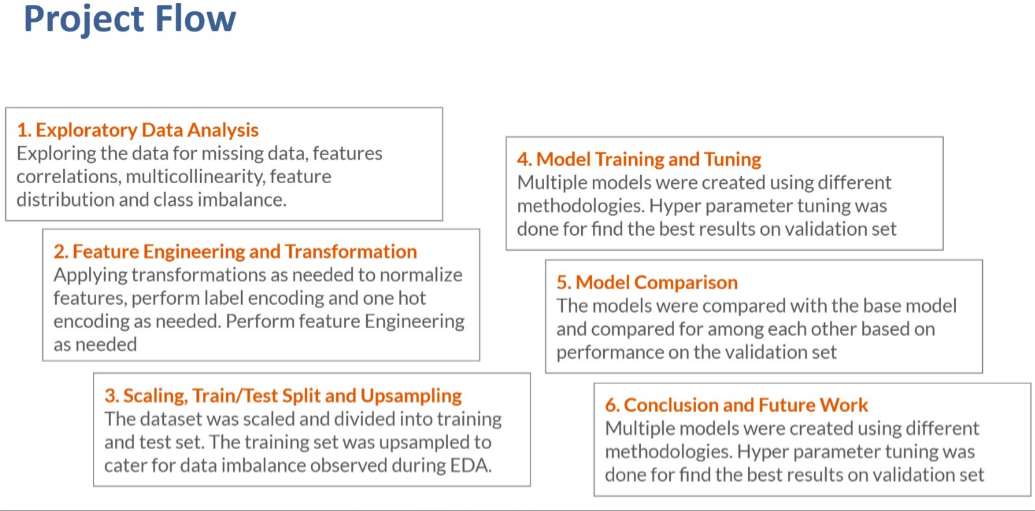

## EDA

Performing the explatory data analysis on the data

Out dataset contains the following columns

In [5]:
df.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  int64  
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              20000 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               20000 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

Analyzing sample data from the dataframe

In [7]:
df.head(3).T

,0,1,2
Age,45,38,47
AnnualIncome,39948,39709,40724
CreditScore,617,628,570
EmploymentStatus,Employed,Employed,Employed
EducationLevel,Master,Associate,Bachelor
Experience,22,15,26
LoanAmount,13152,26045,17627
LoanDuration,48,48,36
MaritalStatus,Married,Single,Married
NumberOfDependents,2,1,2


### Missing Data

No missing data is observed in the dataset.

We are not seeing any missing data as can be seen below.

In [8]:
df.isna().sum()

Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
InterestRate                  0
MonthlyL

### Predictors Categorization

Categorizing the data into numerical and categorical data

In [9]:
categorical_columns = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'BankruptcyHistory',
                       'PreviousLoanDefaults']
ohe_columns = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']
numerical_columns = ['Age',	'AnnualIncome', 'CreditScore', 'Experience',  'LoanAmount',	'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 
                     'CreditCardUtilizationRate','NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PaymentHistory', 
                     'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance',  'TotalAssets',  'TotalLiabilities', 'MonthlyIncome',
                     'UtilityBillsPaymentHistory', 'JobTenure',  'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 
                     'TotalDebtToIncomeRatio']

log_numerical_columns = ['Age',	'AnnualIncome', 'CreditScore', 'Experience',  'LoanAmount',	'MonthlyDebtPayments', 'PaymentHistory',
                         'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
                         'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']
log_numerical_columns_name = [col+'log' for col in log_numerical_columns]
discrete_columns = ['LoanDuration', 'NumberOfDependents', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'LengthOfCreditHistory', 'JobTenure']
numerical_columns_plog = log_numerical_columns_name + ['CreditCardUtilizationRate', 'DebtToIncomeRatio'] + discrete_columns


In [10]:
random_state=109
cv=5
kfold=KFold(n_splits=cv)

### Analyzing the numerical predictors

- The data columns show that the data is within the range.
- The data doesn't seem to contain any outliers based upon the general understanding of the fields and anayzing the min and max values.
- We'll analyze the histogram to check the data distribution to analyze if any data transformation is needed.
- The scale of the data is different for different metrics. This means that to get better results we'll need to scale the data.
- Data scaling is important since scaled data helps in loss function convergence and creates stability for the model.

In [11]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,2.000000e+04,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,3.625241e+04,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,4.725151e+04,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,3.720000e+02,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,1.119675e+04,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,2.220300e+04,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,4.314650e+04,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,1.417302e+06,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000


### Analyzing the categorial predictors

- There are many categorical fields having strings values. These values needs to be converted into discrete variables before applying any model.
- Some of the data categories are asymmetric. We shall keep this in mind while performing the data split. Stratified data split will be a better choice for train test split.
- The categorical data with strings value needs to be converted into discrete numeric variables before feeding the data to our models.

In [12]:
df[categorical_columns].value_counts().T

EmploymentStatus  EducationLevel  MaritalStatus  HomeOwnershipStatus  LoanPurpose         BankruptcyHistory  PreviousLoanDefaults
Employed          High School     Married        Mortgage             Home                0                  0                       280
                  Bachelor        Married        Mortgage             Home                0                  0                       241
                  High School     Married        Mortgage             Debt Consolidation  0                  0                       236
                  Bachelor        Married        Mortgage             Debt Consolidation  0                  0                       231
                  High School     Married        Rent                 Home                0                  0                       200
                                                                                                                                    ... 
Self-Employed     Doctorate       Divorced      

In [13]:
for col in categorical_columns:
    print(df[col].value_counts(normalize=True), "\n"*2)

EmploymentStatus
Employed         0.85180
Self-Employed    0.07865
Unemployed       0.06955
Name: proportion, dtype: float64 


EducationLevel
Bachelor       0.3027
High School    0.2954
Associate      0.2017
Master         0.1525
Doctorate      0.0477
Name: proportion, dtype: float64 


MaritalStatus
Married     0.50205
Single      0.30390
Divorced    0.14410
Widowed     0.04995
Name: proportion, dtype: float64 


HomeOwnershipStatus
Mortgage    0.39695
Rent        0.30435
Own         0.19690
Other       0.10180
Name: proportion, dtype: float64 


LoanPurpose
Home                  0.29625
Debt Consolidation    0.25135
Auto                  0.20170
Education             0.15040
Other                 0.10030
Name: proportion, dtype: float64 


BankruptcyHistory
0    0.9476
1    0.0524
Name: proportion, dtype: float64 


PreviousLoanDefaults
0    0.89995
1    0.10005
Name: proportion, dtype: float64 




### Feature Engineering

For data categories less than 5% of samples, we can apply feature engineering by merging these categories with other groups. The reason for doing that will be to create a more generalized model.

- From the data below, the lowest class is in EducationalLevel with 4.77%. This data is close enough to 5%, so we'll keep it in it's original form.
- For MaritalStatus, Widowed have 4.995% of total samples.
- The dataset doesn't need any feature engineering and we can use the data in its original form.

In [14]:
for col in categorical_columns:
    display(100* df[col].value_counts(normalize=True))
    print("\n")

EmploymentStatus
Employed         85.180
Self-Employed     7.865
Unemployed        6.955
Name: proportion, dtype: float64

EducationLevel
Bachelor       30.27
High School    29.54
Associate      20.17
Master         15.25
Doctorate       4.77
Name: proportion, dtype: float64

MaritalStatus
Married     50.205
Single      30.390
Divorced    14.410
Widowed      4.995
Name: proportion, dtype: float64

HomeOwnershipStatus
Mortgage    39.695
Rent        30.435
Own         19.690
Other       10.180
Name: proportion, dtype: float64

LoanPurpose
Home                  29.625
Debt Consolidation    25.135
Auto                  20.170
Education             15.040
Other                 10.030
Name: proportion, dtype: float64

BankruptcyHistory
0    94.76
1     5.24
Name: proportion, dtype: float64

PreviousLoanDefaults
0    89.995
1    10.005
Name: proportion, dtype: float64

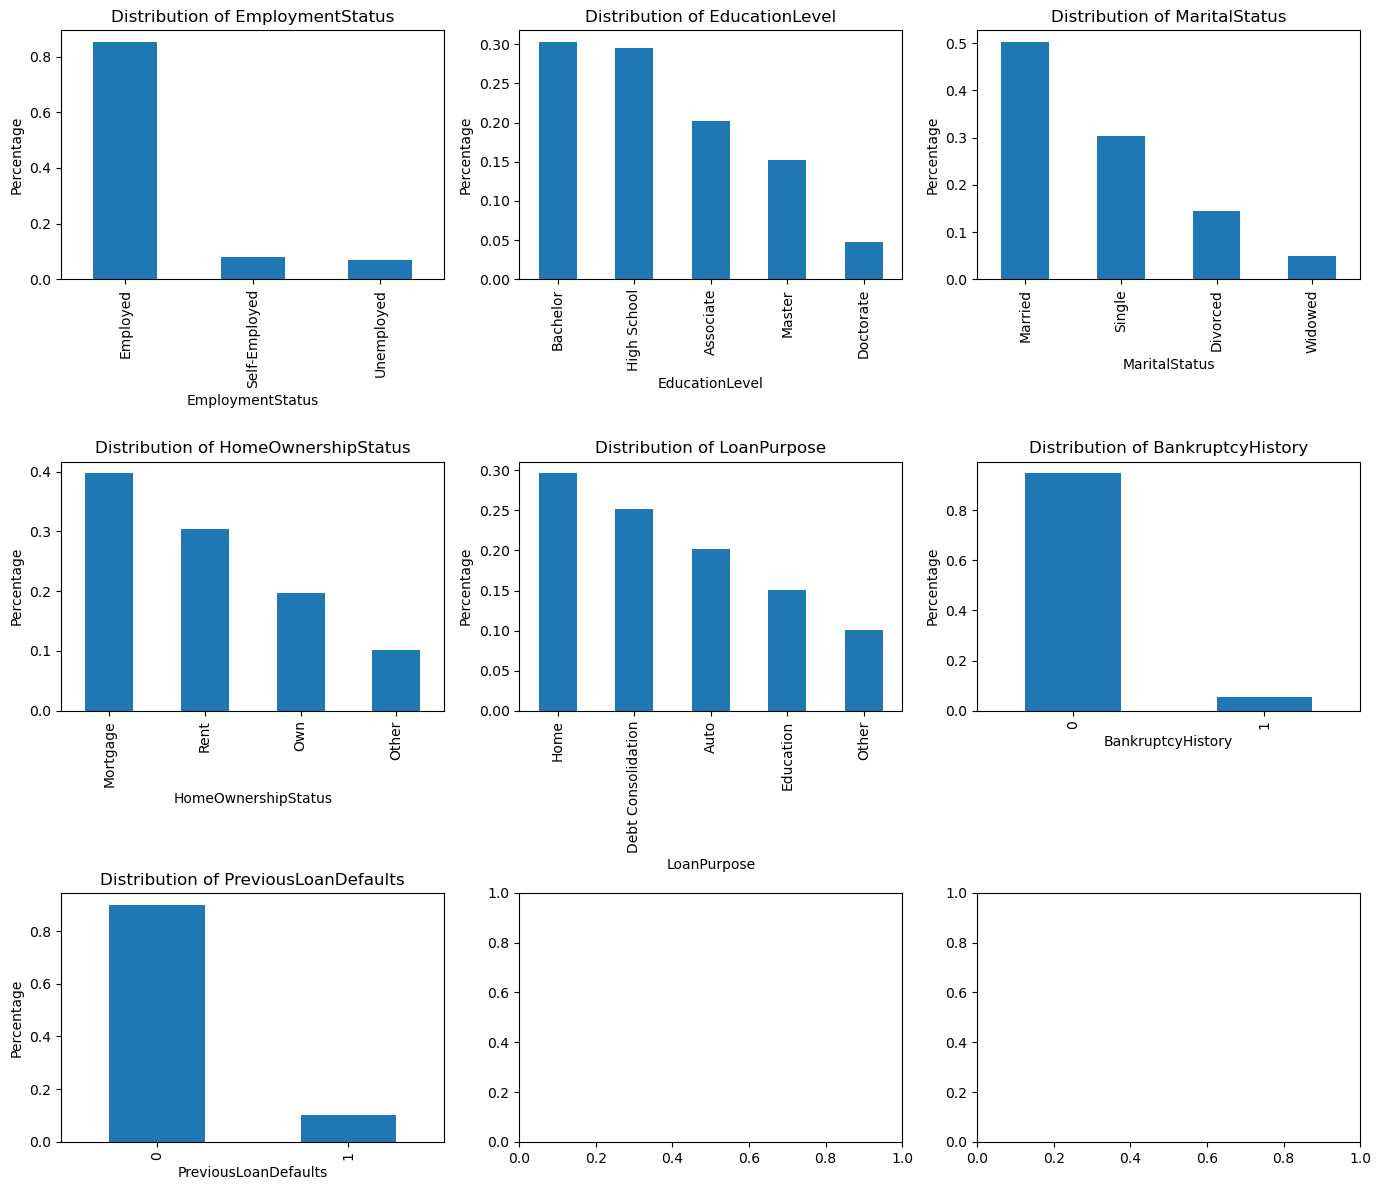

In [15]:
nrows, ncols = 3, 3
fig, ax = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
# ax = ax.flatten()
ax = ax.ravel()
for col, ax in zip(categorical_columns, ax):
    df[col].value_counts(normalize=True).plot(kind='bar', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage')
plt.tight_layout()
plt.show()


## Correlations

### Numerical Predictors:
The following predictors as per the histograms below are showing separation for admitted and non-admitted. This implies that there may be moderate to strong correlation with the admitted cases below.

- AnnualIncome
- MonthlyIncome
- TotalDebtToIncomeRatio

The other predictors are showing low to moderate correlations as per the histograms below.

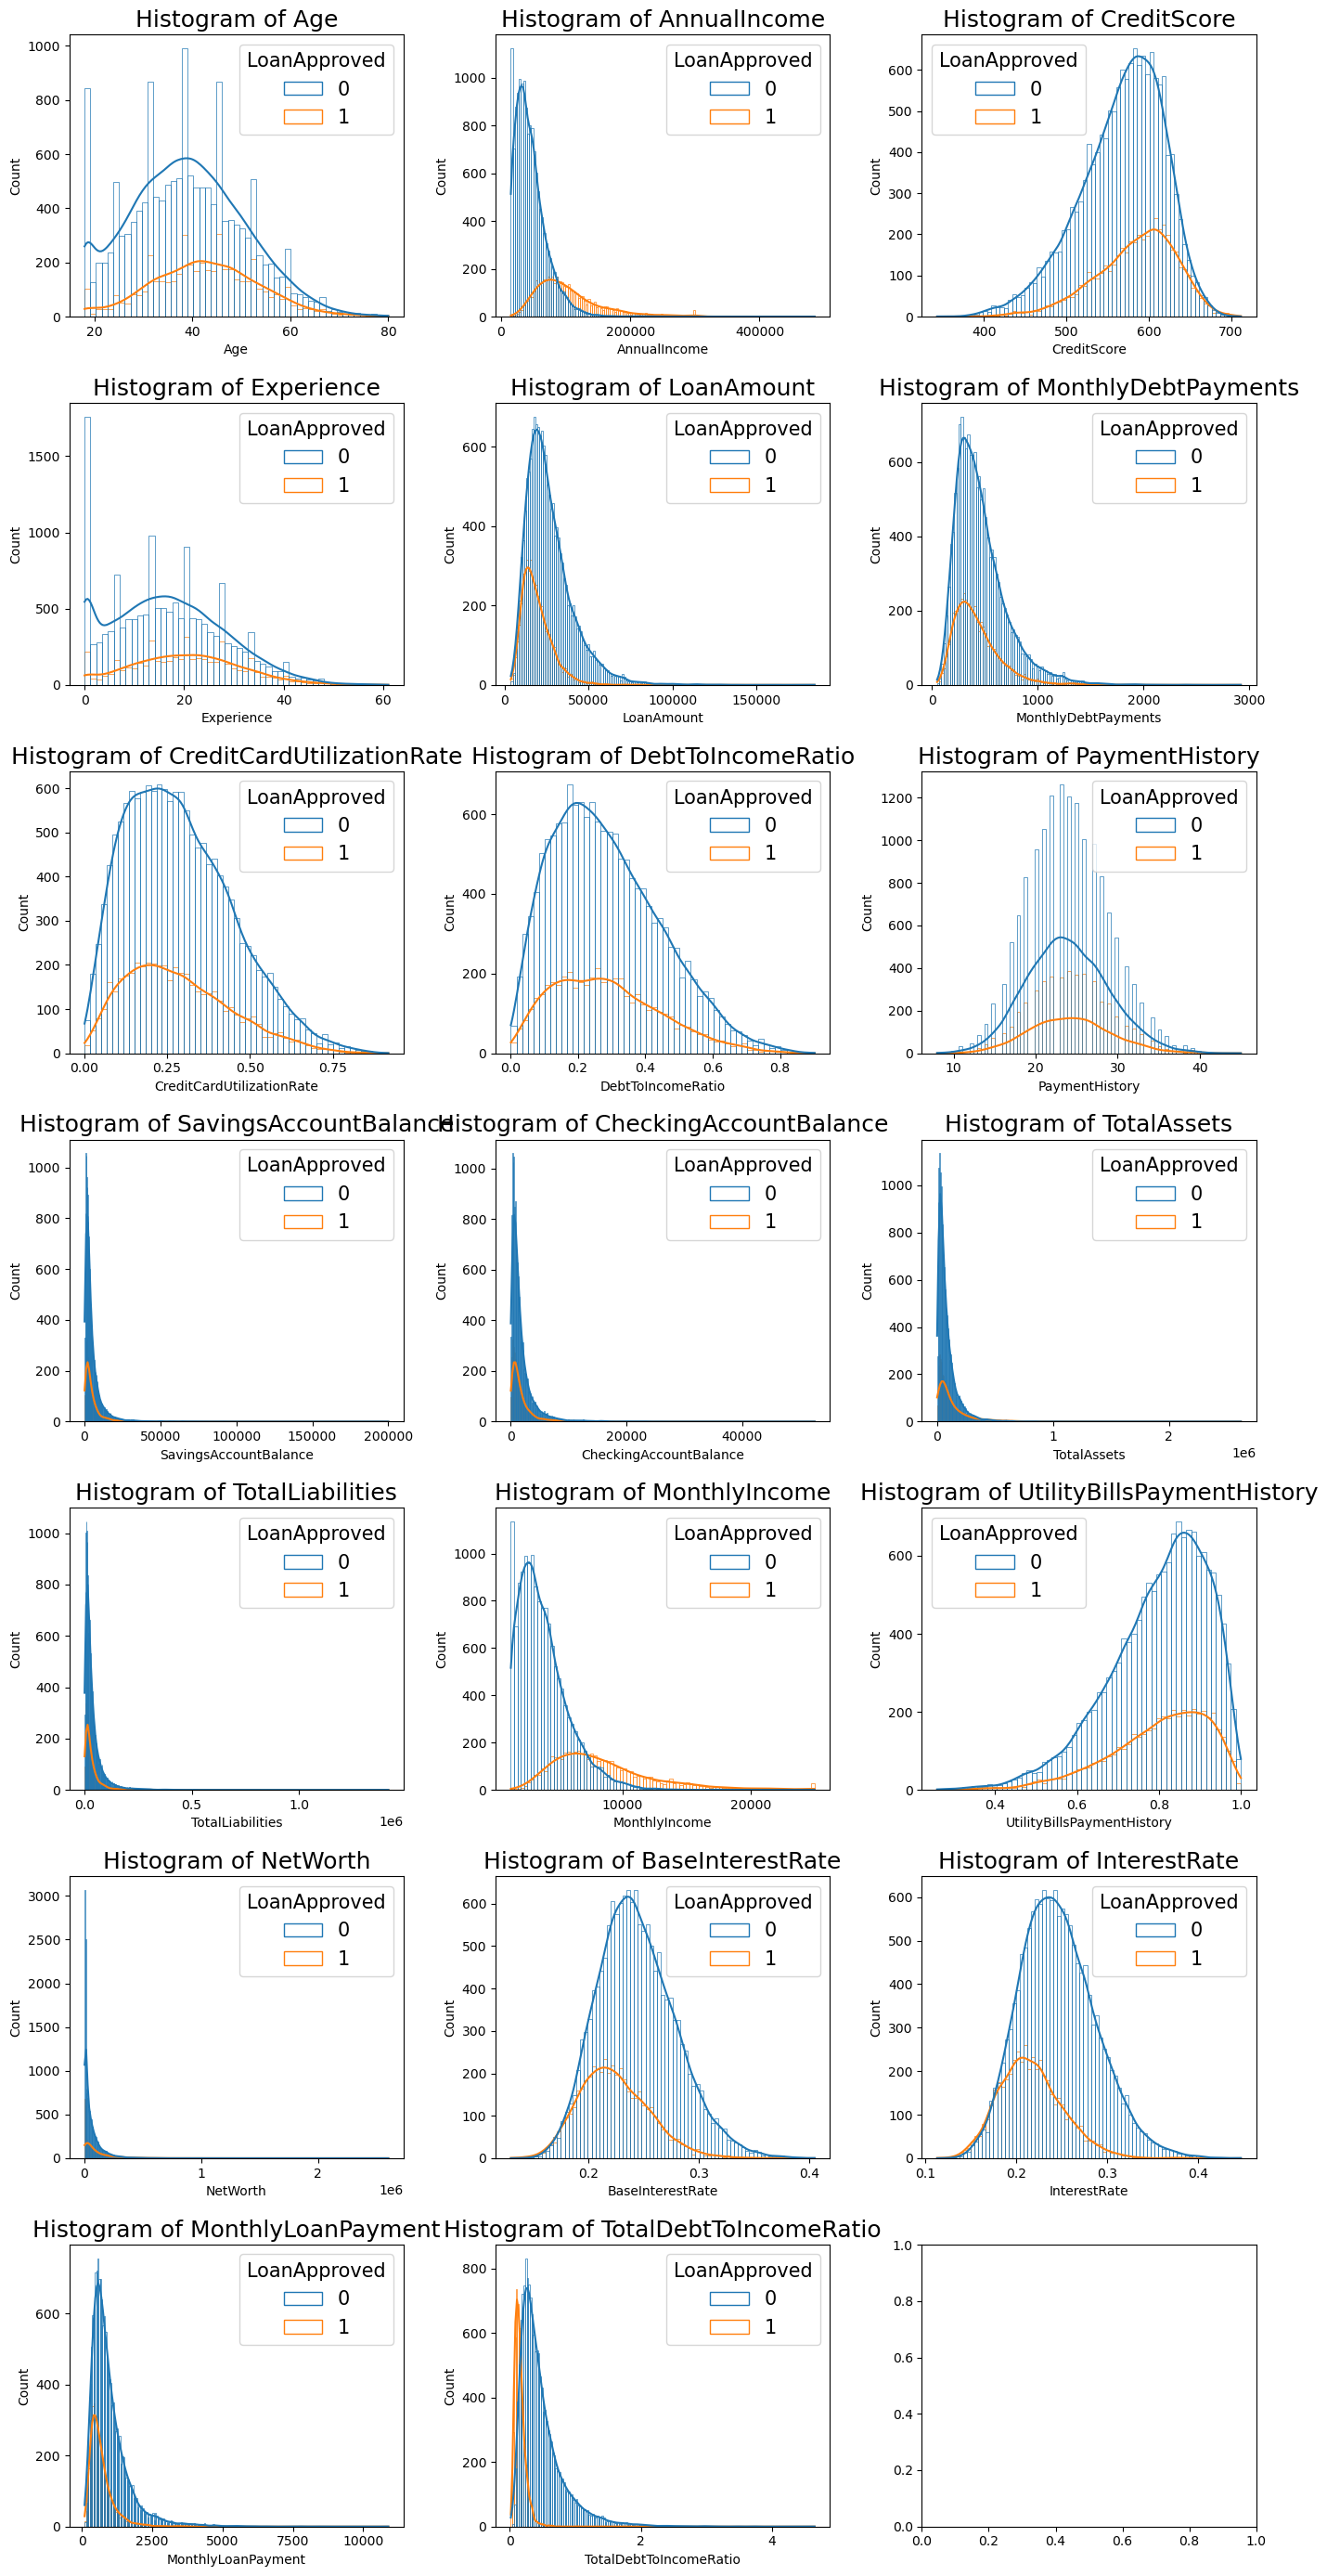

In [16]:
nrows, ncols = 7, 3
fig, ax = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
plt.rcParams.update({'font.size': 15})
# ax = ax.flatten()
ax = ax.ravel()
hist_plot_cols = [col for col in numerical_columns if col not in discrete_columns]
for col, ax in zip(hist_plot_cols, ax):
    sns.histplot(df, x=col, hue='LoanApproved', kde=True, fill=None, ax=ax)
    ax.set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

### Discrete Predictors
The below boxplots are for discrete predictors. As per the graphs below, we are seeing moderate to strong correlation for the following
- LengthOfCreditHistory
  
The fields below are showing low to moderate correlation

- LoanDuration
- NumberOfDepenndents

Rest of the predictors below are not showing much relationship

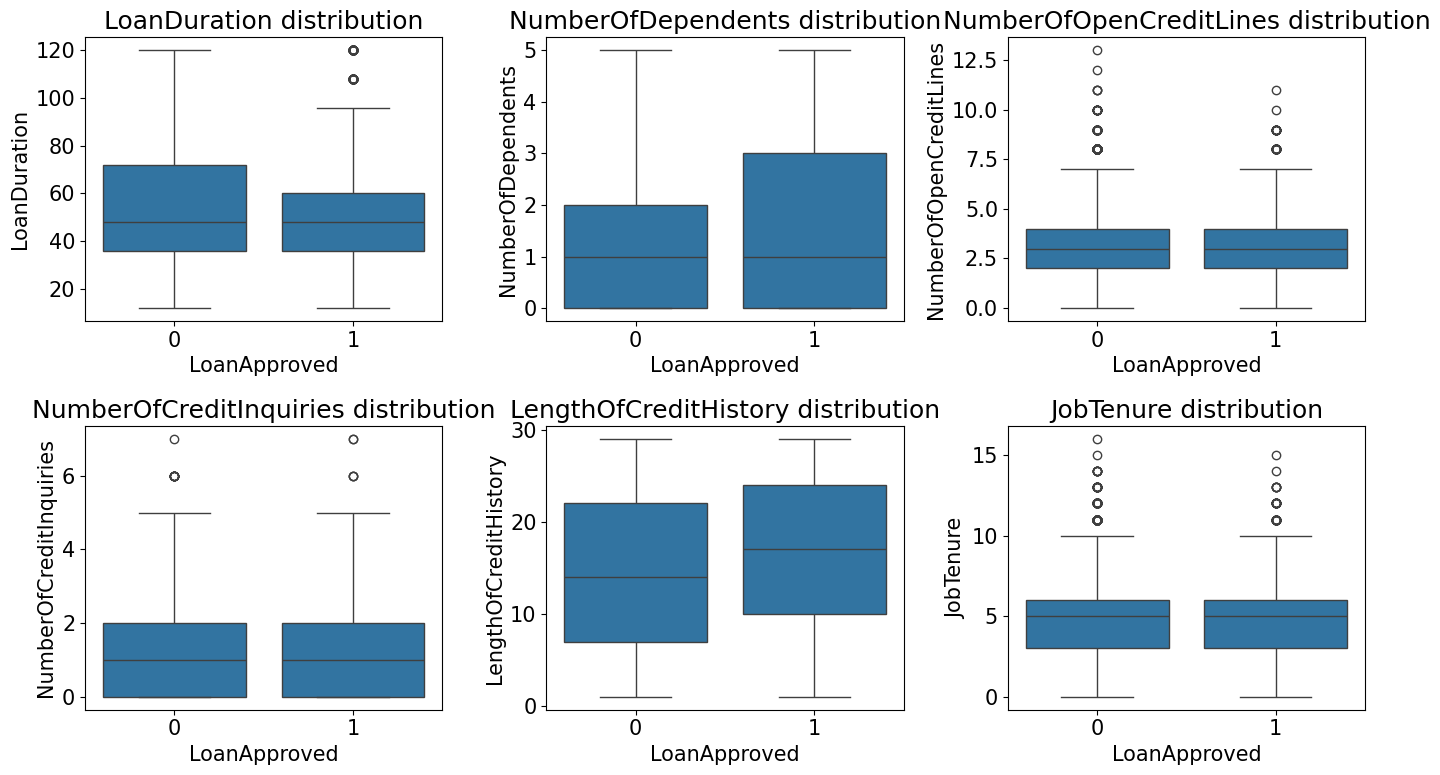

In [17]:
nrows, ncols = 2, 3
fig, ax = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
# ax = ax.flatten()
ax = ax.ravel()
for col, ax in zip(discrete_columns, ax):
    sns.boxplot(df, y=col, x='LoanApproved', ax=ax)
    ax.set_title(f'{col} distribution')
plt.tight_layout()
plt.show()

### Categorical Predictors
The following predictors are showing low to strong relationship based upon the countplots, contingency tables and cross-classification tables, the following fields are seen to be important.

- EmploymentStatus
- EducationLevel
- BankruptcyHistory
- PreviousLoanDefaults


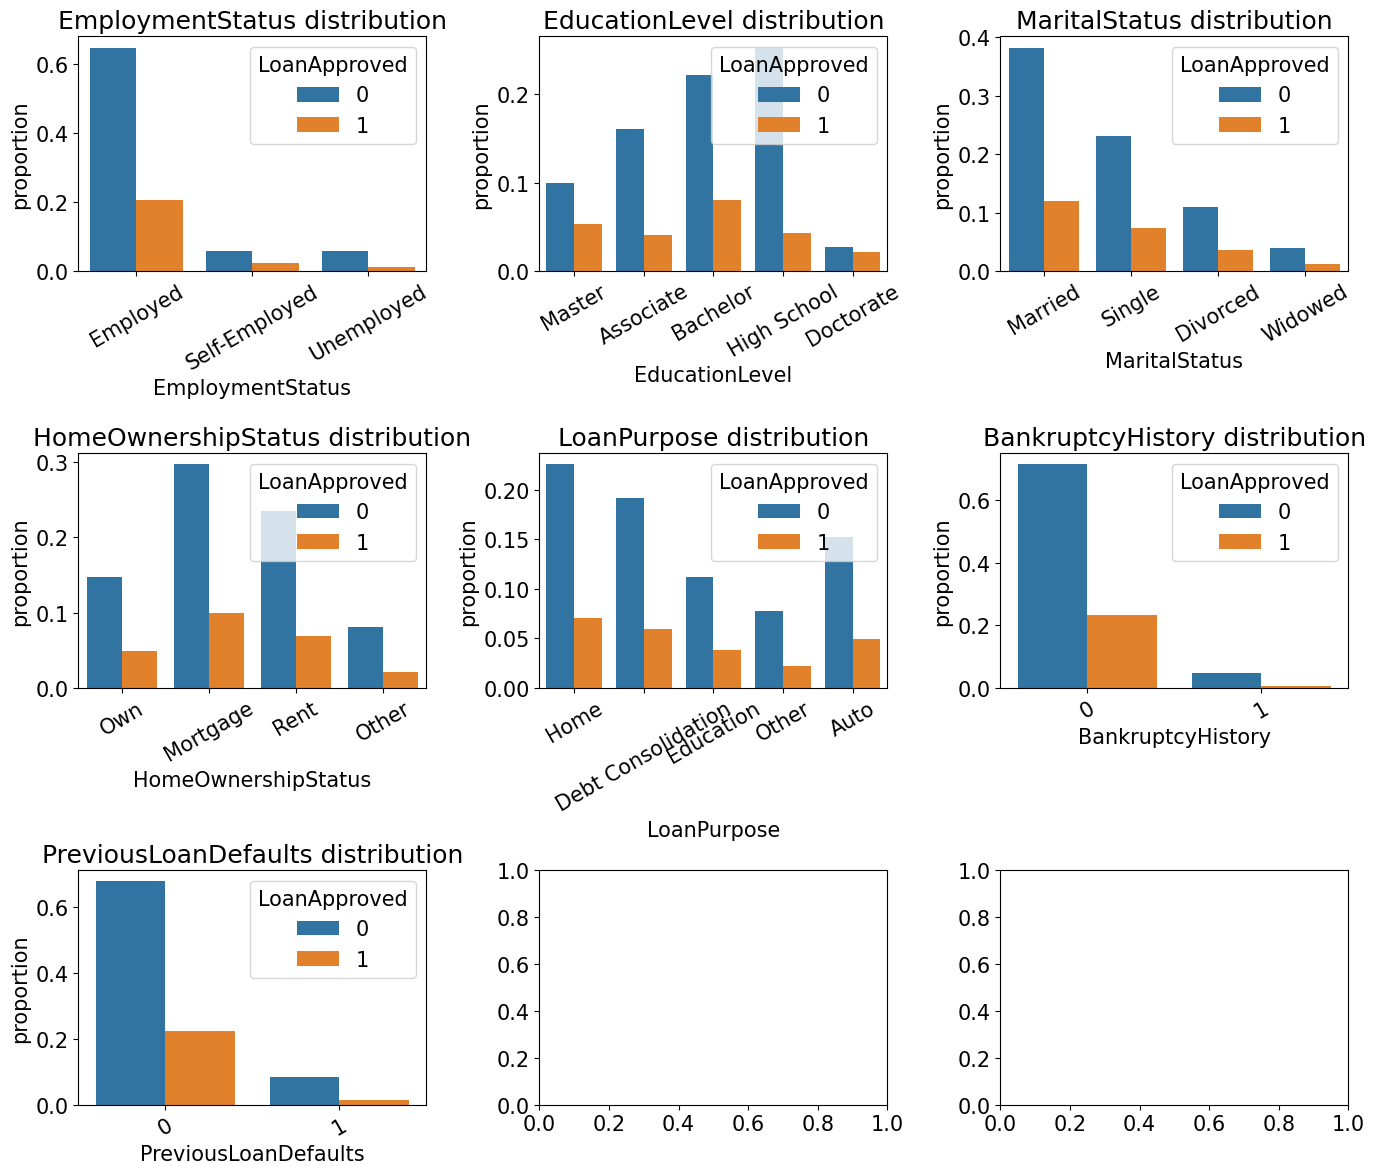

In [18]:
nrows, ncols = 3, 3
fig, ax = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
# ax = ax.flatten()
ax = ax.ravel()
for col, ax in zip(categorical_columns, ax):
    sns.countplot(df, x=col, hue='LoanApproved', ax=ax, stat='proportion')
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(f'{col} distribution')
plt.tight_layout()
plt.show()

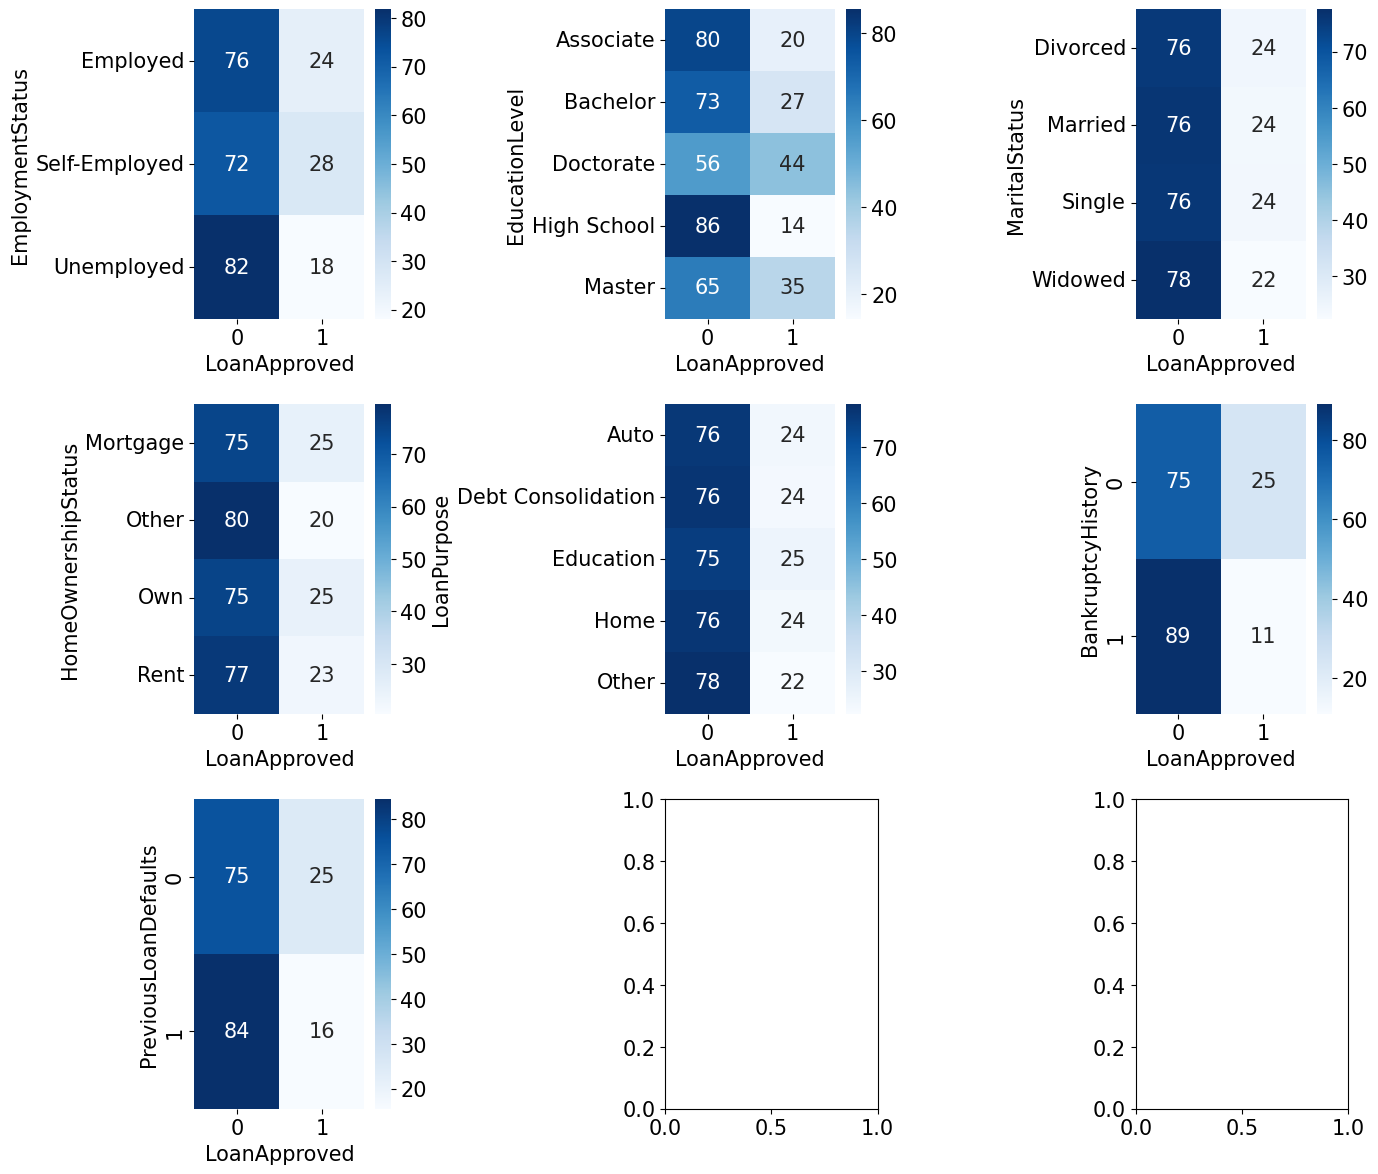

In [19]:
# Add contigency table and visual
nrows, ncols = 3, 3
fig, ax = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
# ax = ax.flatten()
ax = ax.ravel()

for col, ax in zip(categorical_columns, ax):
    ct = pd.crosstab(df[col], df['LoanApproved'], normalize=True)
    # ct = pd.crosstab(df['LoanApproved'], df[col], normalize=True)
    percentages = ct.div(ct.sum(axis=1), axis=0) * 100
    # sns.heatmap(ct, annot=True, cmap='Blues', ax=ax)
    sns.heatmap(percentages, annot=True, cmap='Blues', ax=ax)
plt.tight_layout()
plt.show()

In [20]:
for col in categorical_columns:
    display(pd.crosstab(df[col], df['LoanApproved'], normalize=True))

LoanApproved,0,1
EmploymentStatus,,
Employed,0.64735,0.20445
Self-Employed,0.05675,0.02190
Unemployed,0.05690,0.01265


LoanApproved,0,1
EducationLevel,,
Associate,0.16050,0.04120
Bachelor,0.22205,0.08065
Doctorate,0.02670,0.02100
High School,0.25275,0.04265
Master,0.09900,0.05350


LoanApproved,0,1
MaritalStatus,,
Divorced,0.10880,0.03530
Married,0.38230,0.11975
Single,0.23115,0.07275
Widowed,0.03875,0.01120


LoanApproved,0,1
HomeOwnershipStatus,,
Mortgage,0.29710,0.09985
Other,0.08095,0.02085
Own,0.14790,0.04900
Rent,0.23505,0.06930


LoanApproved,0,1
LoanPurpose,,
Auto,0.15275,0.04895
Debt Consolidation,0.19225,0.05910
Education,0.11235,0.03805
Home,0.22575,0.07050
Other,0.07790,0.02240


LoanApproved,0,1
BankruptcyHistory,,
0,0.7144,0.2332
1,0.0466,0.0058


LoanApproved,0,1
PreviousLoanDefaults,,
0,0.6765,0.22345
1,0.0845,0.01555


### Feature Transformation

Based upon the above plots, we'll be applying log transformation to normalize the distribution of some of the numerical features


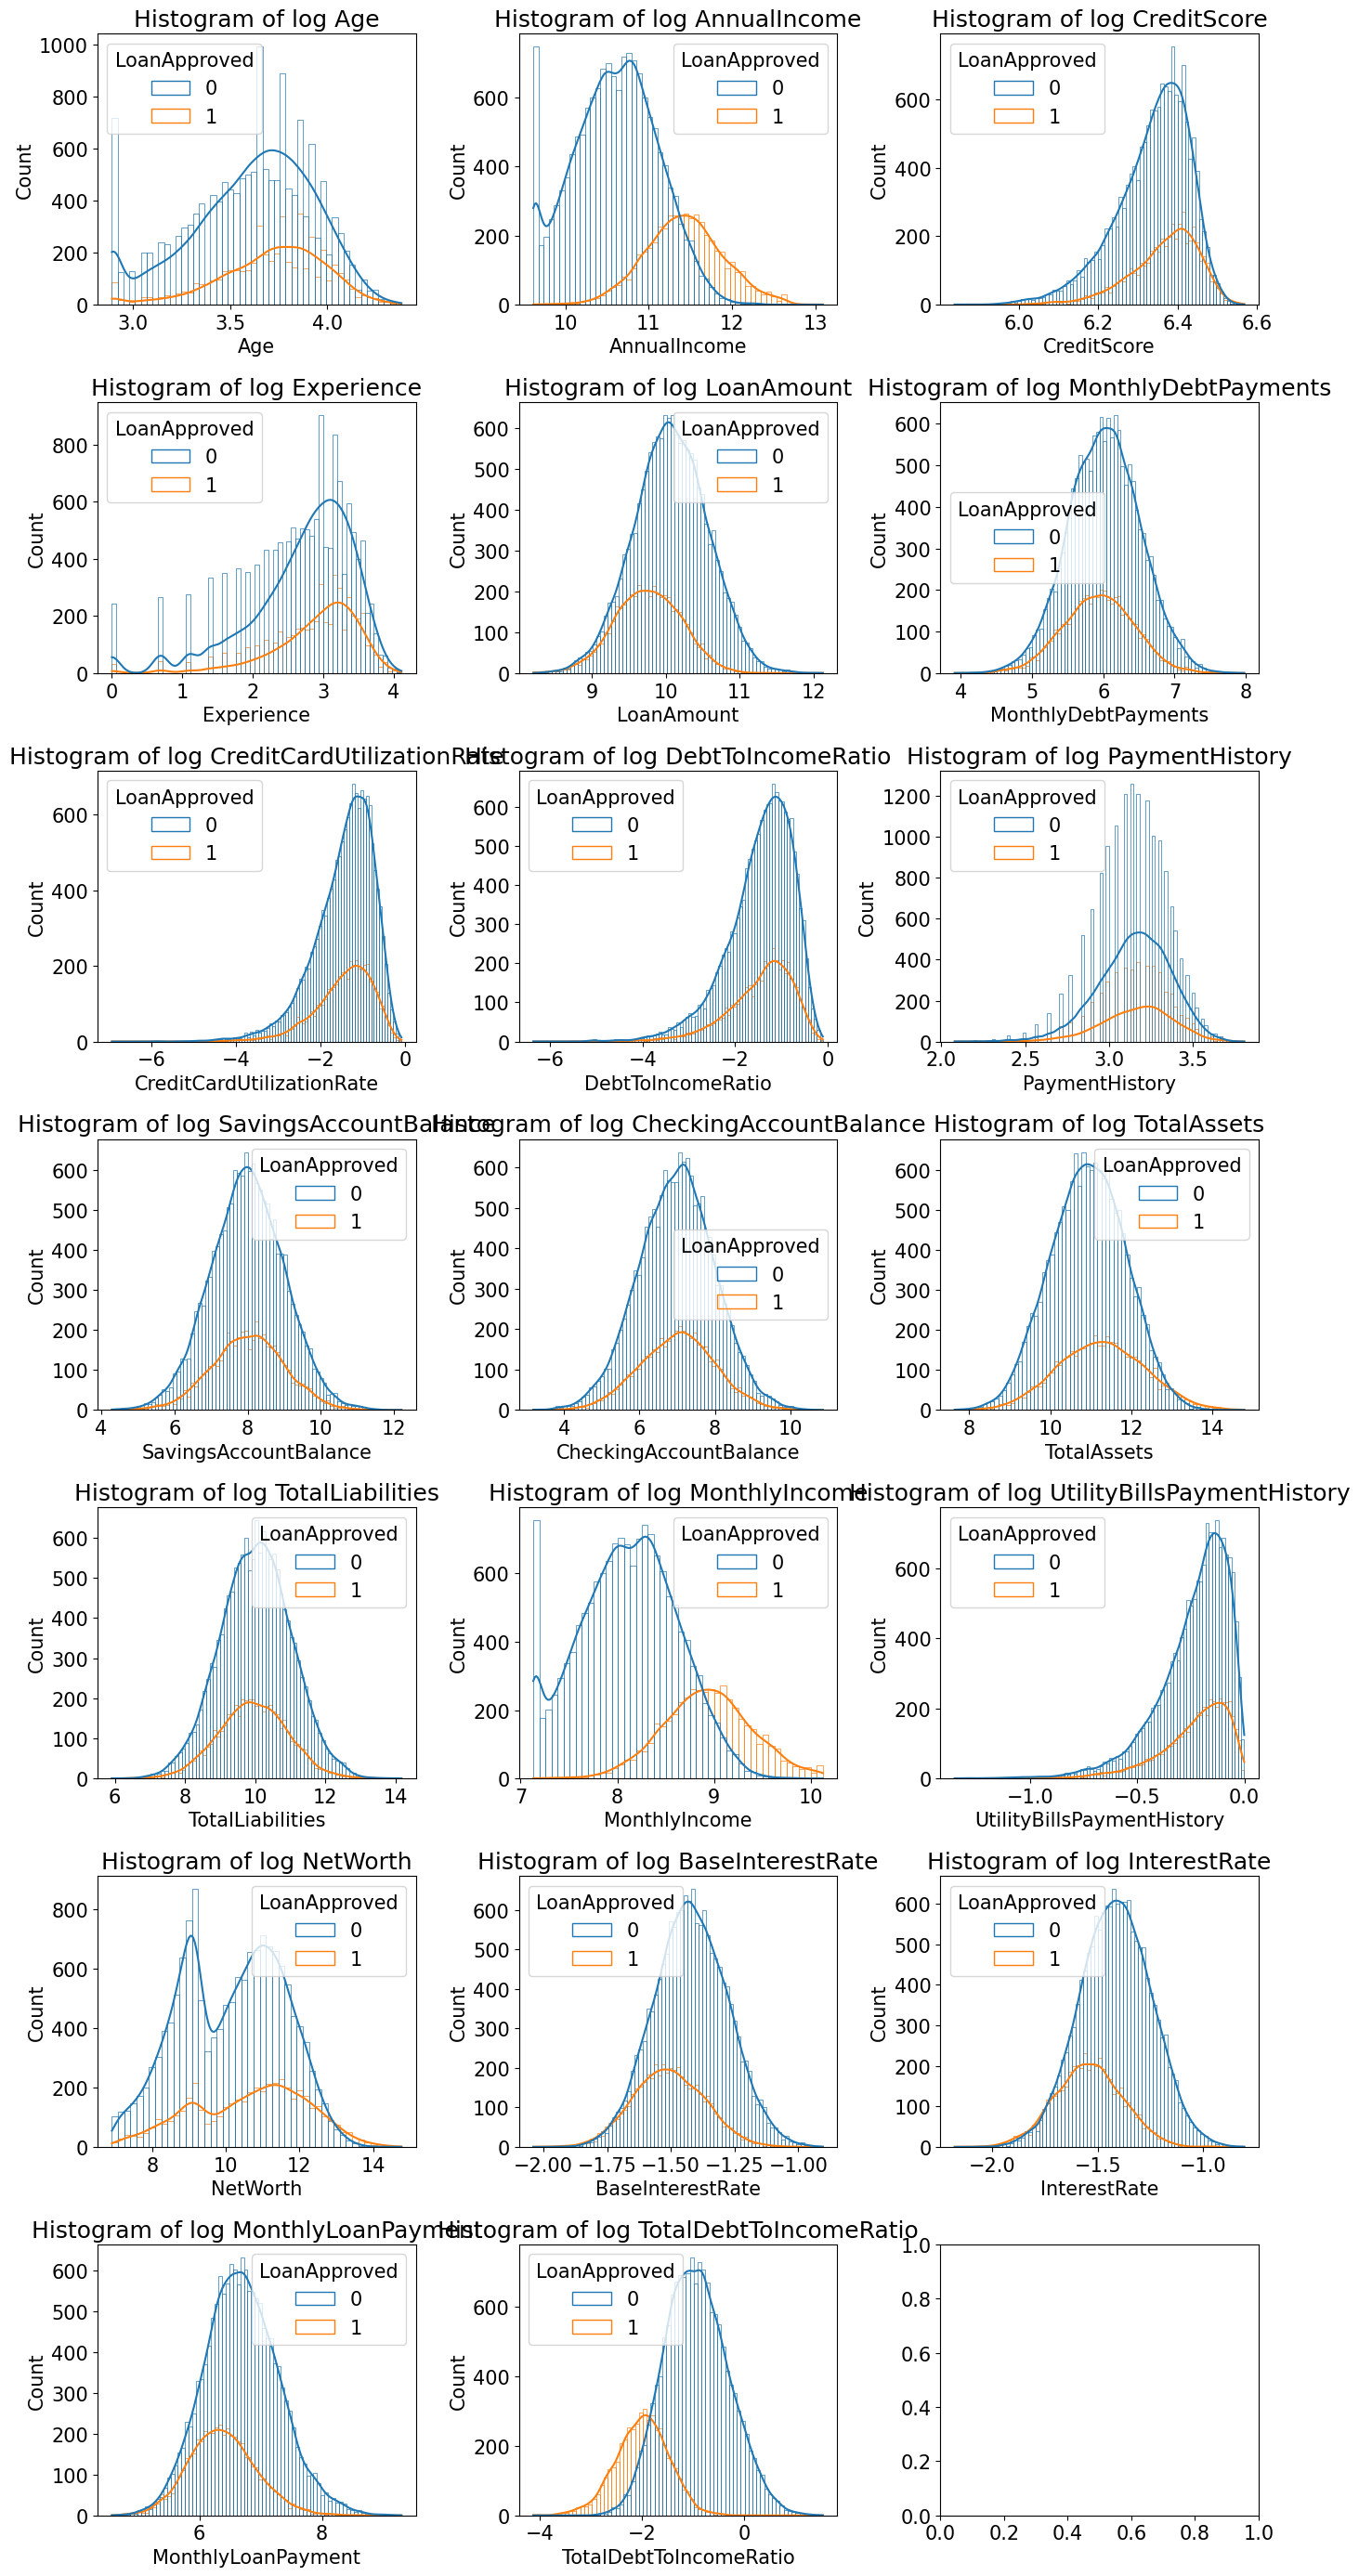

In [21]:
warnings.filterwarnings('ignore')

nrows, ncols = 7, 3
fig, ax = plt.subplots(nrows, ncols, figsize=(14, nrows*4))
# ax = ax.flatten()
ax = ax.ravel()
hist_plot_cols = [col for col in numerical_columns if col not in discrete_columns]
for col, ax in zip(hist_plot_cols, ax):
    sns.histplot(df, x=np.log(df[col]), hue='LoanApproved', kde=True, fill=None, ax=ax)
    ax.set_title(f'Histogram of log {col}')
    
plt.tight_layout()
plt.show()

In [22]:
np.log(df[numerical_columns])

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,3.806662,10.595334,6.424869,3.091042,9.484329,3.871201,0.693147,5.209486,-1.037279,0.000000,...,11.892122,9.861780,8.110427,-0.321622,2.397895,11.751375,-1.611179,-1.480211,6.039793,-1.708832
1,3.637586,10.589333,6.442540,2.708050,10.167581,3.871201,0.000000,6.206576,-2.432387,1.609438,...,10.881889,9.168997,8.104426,-0.067067,1.098612,10.683019,-1.574819,-1.604067,6.677152,-0.941987
2,3.850148,10.614573,6.345636,3.258097,9.777187,3.583519,0.693147,6.804615,-1.984756,0.693147,...,10.133646,11.766590,8.129666,-0.136690,1.791759,8.557375,-1.524973,-1.548587,6.501900,-0.771851
3,4.060443,11.143078,6.300786,3.526361,10.542654,4.564348,0.000000,6.626718,-1.318310,0.693147,...,11.560019,8.588583,8.658172,-0.109642,1.609438,11.507430,-1.202647,-1.200941,6.954168,-1.161238
4,3.610918,11.545044,6.386879,2.833213,9.125218,3.583519,0.000000,5.613128,-1.137763,-inf,...,12.406173,9.757652,9.060137,-0.060420,1.609438,12.332789,-1.623618,-1.737327,5.799635,-2.656267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,3.784190,10.314935,6.375025,2.944439,10.107285,3.583519,1.098612,6.511745,-2.289789,1.609438,...,11.301822,10.151987,7.830028,-0.190897,0.000000,10.921016,-1.532380,-1.631817,6.808783,-0.465628
19996,4.025352,10.804583,6.340359,3.496508,10.158827,3.583519,1.609438,6.025866,-0.751163,0.693147,...,11.150103,8.624971,8.319677,-0.202584,1.098612,11.066670,-1.481405,-1.613605,6.865261,-1.095364
19997,3.784190,10.798718,6.469250,2.995732,10.519565,4.276666,1.098612,6.238325,-1.529721,1.098612,...,11.592808,8.445267,8.313811,-0.119667,1.098612,11.548901,-1.471708,-1.483835,6.851637,-1.029383
19998,4.094345,10.621937,6.327937,3.583519,9.599676,4.276666,1.098612,6.893656,-1.008522,1.386294,...,10.002654,9.348797,8.137030,-0.169855,1.609438,9.268609,-1.387255,-1.328506,6.019003,-0.894827


In [23]:
df[log_numerical_columns_name] = np.log(df[log_numerical_columns]+1e-12)

In [24]:
df.drop(columns=log_numerical_columns, axis=1, inplace=True)

In [25]:
df.head()

,EmploymentStatus,EducationLevel,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,...,CheckingAccountBalancelog,TotalAssetslog,TotalLiabilitieslog,MonthlyIncomelog,UtilityBillsPaymentHistorylog,NetWorthlog,BaseInterestRatelog,InterestRatelog,MonthlyLoanPaymentlog,TotalDebtToIncomeRatiolog
0,Employed,Master,48,Married,2,Own,0.354418,1,2,0.358336,...,7.091742,11.892122,9.861780,8.110427,-0.321622,11.751375,-1.611179,-1.480211,6.039793,-1.708832
1,Employed,Associate,48,Single,1,Mortgage,0.087827,5,3,0.330274,...,8.149024,10.881889,9.168997,8.104426,-0.067067,10.683019,-1.574819,-1.604067,6.677152,-0.941987
2,Employed,Bachelor,36,Married,2,Rent,0.137414,2,0,0.244729,...,6.796824,10.133646,11.766590,8.129666,-0.136690,8.557375,-1.524973,-1.548587,6.501900,-0.771851
3,Employed,High School,96,Single,1,Mortgage,0.267587,2,1,0.436244,...,7.104144,11.560019,8.588583,8.658172,-0.109642,11.507430,-1.202647,-1.200941,6.954168,-1.161238
4,Employed,Associate,36,Married,1,Mortgage,0.320535,0,0,0.078884,...,8.513386,12.406173,9.757652,9.060137,-0.060420,12.332789,-1.623618,-1.737327,5.799635,-2.656267


### Correlation matrix

From the correlation matrix below, we can see that the following fields have high correlation

- Age and Experience
- AnnualIncome and MonthlyIncome
- LoanAmount and MonthlyLoanPayment
- CreditScore, BaseInterestRate and InterestRate
- TotalAssets and Networth
- LoanDuration and InterestRate

These predictors will induce multicollinearity issues in our model. Multicollinearity occurs when two or more independent variables (predictors/features) in a regression model are highly correlated with each other.


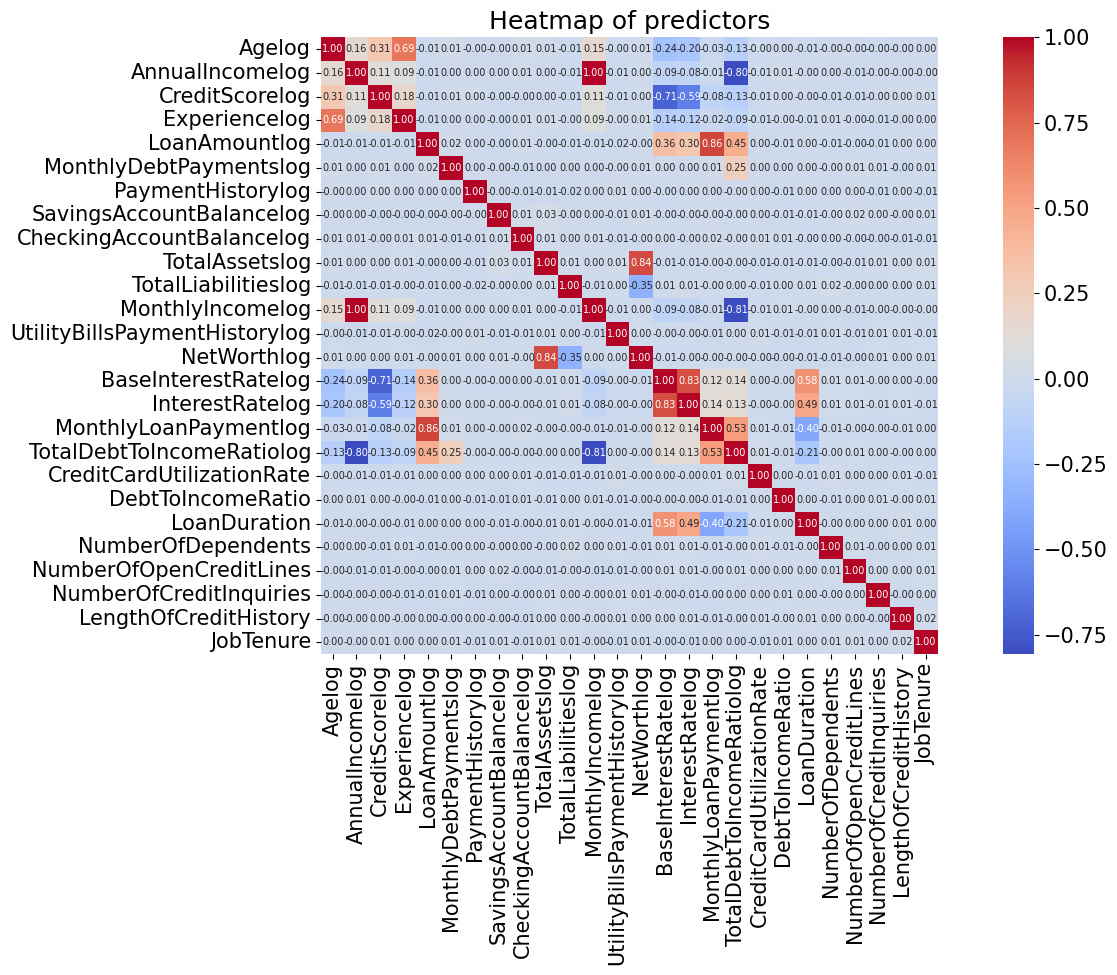

In [26]:
plt.figure(figsize=(15, 10))
# sns.heatmap(df[numerical_columns].corr(), cmap='coolwarm', annot=True, square=True, fmt=".2f", annot_kws={'fontsize': 7})
sns.heatmap(df[numerical_columns_plog].corr(), cmap='coolwarm', annot=True, square=True, fmt=".2f", annot_kws={'fontsize': 7})
plt.title('Heatmap of predictors')
plt.tight_layout()
plt.show()

## Scaling, Train/Test Split and Upsampling

### Scaling

Scaling was done for all the numerical variables. Scaling has been integrated as part of the data pipeline generation

### Label Encoding

In [27]:
label_encoder_dict = {}
for col in categorical_columns:
    label_encoder_dict[col] = LabelEncoder().fit(df[col])
    df[col] = label_encoder_dict[col].transform(df[col])

In [28]:
for l1 in label_encoder_dict.values():
    print(l1.classes_)

['Employed' 'Self-Employed' 'Unemployed']
['Associate' 'Bachelor' 'Doctorate' 'High School' 'Master']
['Divorced' 'Married' 'Single' 'Widowed']
['Mortgage' 'Other' 'Own' 'Rent']
['Auto' 'Debt Consolidation' 'Education' 'Home' 'Other']
[0 1]
[0 1]


### One hot Encoding

One hot encoding was done as part of the dtaa generation pipeline. Please note that we are dropping first categorical variable after one hot encoding for logistic regression models, while for ensembles methods we are retaining all the categorical columns

### Sampling

We'll be using stratified sampling to ensure that the training and test data has the same distribution of classes for the predicted variable.
We also tried doing sampling with symmetry for test set, but the results were not any different. Finally we decided to go with simple startified sampling instead.

In [29]:
df['LoanApproved'].value_counts(), df['LoanApproved'].value_counts(normalize=True)

(LoanApproved
 0    15220
 1     4780
 Name: count, dtype: int64,
 LoanApproved
 0    0.761
 1    0.239
 Name: proportion, dtype: float64)

#### Stratified Sampling

Splitting the data into train test split of 80/20. Since ApplicationDate is not important for us, we'll be dropping ApplicationDate from the dataset.
This has also been integreted as part of the data generation pipeline

In [30]:

# X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['ApplicationDate', 'LoanApproved', 'RiskScore'], axis=1), df['LoanApproved'], 
#                                                     test_size=0.2, stratify=df['LoanApproved'], random_state=random_state)
# X_train.shape, X_test.shape, y_train.shape, y_test.shape

##### Analyzing the predicted variables after the split

In [31]:
# y_train.value_counts(), y_train.value_counts(normalize=True), y_test.value_counts(),  y_test.value_counts(normalize=True)

#### Data Symmetry and Upsampling

As we can see below the data is asymmetric. We have more cases of loan applications being rejected compared to getting approved.
To address this imbalance, we need to upsample the data. There are different techniques for upsampling. Just to name a few.

- Random Oversampling, which duplicates existing samples to upsample
- Smote (Synthetic Minority Over-sampling Technique), which creates synthetic data, by interpolating the minority class samples.

Here we are using Smote for upsampling. Reason for doing that was that smote uses interpolation, rather than duplicating the data during upsampling. This methodology will be helpful in smoothening the boundaries while modeling

In [32]:
df['LoanApproved'].value_counts(), df['LoanApproved'].value_counts(normalize=True)

(LoanApproved
 0    15220
 1     4780
 Name: count, dtype: int64,
 LoanApproved
 0    0.761
 1    0.239
 Name: proportion, dtype: float64)

## Data Generation Pipeline

We are using get_parameter_data function for the data preparation that will be used for different Machine Learning Models evaluation. This includes:

        ◦ Scaling for numerical features
        ◦ One Hot Encoding for categorical features
        ◦ Splitting of Train and Test Data using Stratifying.
        ◦ Data symmetry and up sampling the train data using SMOTE.
        ◦ Applying Polynomial Interactions terms based on function input argument(optionally).

In [33]:
def get_parameter_data(df1, cat_cols=[], num_cols=[], ohe_cols=[], drop_cols=[], ohe_drop='first', test_size=0.2, d_poly=False):
    df=df1.copy()
    random_state=109
    df.drop(drop_cols, axis=1, inplace=True, errors='ignore')
    num_cols_updated = list(set(num_cols).difference(set(drop_cols)))
    cat_cols_updated = list(set(cat_cols).difference(set(drop_cols)))
    std = StandardScaler()
    df[num_cols_updated] = std.fit_transform(df[num_cols_updated])
    ohe = OneHotEncoder(drop=ohe_drop, sparse_output=False)
    dfo = ohe.fit_transform(df[ohe_cols])
    dfo = pd.DataFrame(dfo, columns=ohe.get_feature_names_out())
    df1 = df.drop(ohe_cols, axis=1)
    df_ohe = pd.concat([dfo, df1], axis=1)
    X_train, X_test, y_train, y_test = train_test_split(df_ohe.drop(columns=['ApplicationDate', 'LoanApproved', 'RiskScore'], axis=1, errors='ignore'), 
                                                    df_ohe['LoanApproved'], test_size=test_size, stratify=df_ohe['LoanApproved'], random_state=random_state)
    smote = SMOTE(random_state=random_state) 
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    poly_dict_train = {}
    poly_dict_test = {}
    if d_poly:
        for cat in dfo.columns:
            for num in num_cols:
                poly_dict_train[cat+' '+num] = X_train_sm[cat] * X_train_sm[num]
                poly_dict_test[cat+' '+num] = X_test[cat] * X_test[num]

    X_train_poly = pd.DataFrame(poly_dict_train)
    X_train_sm = pd.concat([X_train_sm, X_train_poly], axis=1)
    X_test_poly = pd.DataFrame(poly_dict_test)
    X_test = pd.concat([X_test, X_test_poly], axis=1)

    return X_train_sm, X_test, y_train_sm, y_test


## Performance Metrics Function

The function below will be used to run the performance metrics test

In [34]:
## Getting performance metrics for our model
random_state = 109
cv=5
def get_metrics(model_name, model, x_train, y_train, x_test, y_test, scoring='f1', cv=5):
    metric_dict = {}
    metric_dict['model_name'] = model_name
    metric_dict['model'] = model
    # metric_dict['train_score'] = model.score(x_train, y_train)
    y_train_hat = model.predict(x_train)
    y_test_hat = model.predict(x_test)
    y_train_prob_hat = cross_val_predict(model, x_train, y_train, cv=cv, n_jobs=-1, method='predict_proba')
    fpr, tpr, threshold = roc_curve(y_train, y_train_prob_hat[:,1])
    roc_auc = roc_auc_score(y_train, y_train_prob_hat[:,1])
    # metric_dict['fpr'] = fpr
    # metric_dict['tpr'] = tpr
    # metric_dict['threshold'] = threshold
    
    metric_dict['accuracy_training'] = accuracy_score(y_train, y_train_hat)
    metric_dict['accuracy_CV'] = cross_val_score(model, x_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1 ).mean().item()
    metric_dict['f1_score_training'] = f1_score(y_train, y_train_hat).item()
    metric_dict['f1_score_CV'] = cross_val_score(model, x_train, y_train, cv=cv, scoring=scoring, n_jobs=-1 ).mean().item()
    metric_dict['auc'] = roc_auc.item()
    metric_dict['accuracy_test'] = model.score(x_test, y_test)
    metric_dict['f1_score_test'] = f1_score(y_test, y_test_hat).item()
    
    return metric_dict, tpr, fpr, threshold

In [35]:
model_performance = []

## Model Training and Tuning

### Base Model
For our base model, we are using our EDA and using predictors which are showing some relationship/correlation with the predicted variable. These predictors are listed below.

- AnnualIncome
- MonthlyIncome
- TotalDebtToIncomeRatio
- LengthOfCreditHistory
- EmploymentStatus
- EducationLevel
- BankruptcyHistory
- PreviousLoanDefaults

In [37]:
#Getting data for Base Model
warnings.filterwarnings('ignore')
cols_obs = ['AnnualIncomelog', 'MonthlyIncomelog', 'TotalDebtToIncomeRatiolog', 'LengthOfCreditHistorylog', 
            'EmploymentStatus', 'EducationLevel', 'BankruptcyHistory','PreviousLoanDefaults']


x_train_obs, x_test_obs, y_train_obs, y_test_obs= get_parameter_data(df, cat_cols = categorical_columns , num_cols=numerical_columns_plog ,drop_cols=[], 
                                   ohe_cols=ohe_columns, ohe_drop=None, d_poly=False)

col_obs_sel = [col for col in x_train_obs.columns if col.split("_")[0] in cols_obs ]
x_train_obs, x_test_obs = x_train_obs[col_obs_sel], x_test_obs[col_obs_sel]

In [38]:
# Base Model
lg_obs = LogisticRegression(penalty=None, max_iter=1000, n_jobs=-1)
lg_obs.fit(x_train_obs, y_train_obs)
lg_obs_metric, lg_obs_tpr, lg_obs_fpr, _ = get_metrics('logistic_base', lg_obs, x_train_obs, y_train_obs, x_test_obs, y_test_obs)

In [39]:
model_performance.append(lg_obs_metric)
lg_obs_metric

{'model_name': 'logistic_base',
 'model': LogisticRegression(max_iter=1000, n_jobs=-1, penalty=None),
 'accuracy_training': 0.8627628120893561,
 'accuracy_CV': 0.860915994042603,
 'f1_score_training': 0.8646634810075322,
 'f1_score_CV': 0.862519890001623,
 'auc': 0.9387428722797135,
 'accuracy_test': 0.85125,
 'f1_score_test': 0.7325842696629213}

As we can see, that BankruptcyHistory and PreviousLoanDefault have the highest absolute value of the coefficients. The negative sign shows that these coefficients have negative impact on the loan approval. Since MonthlyIncome and AnnualIncome had multicolinearlity, we can see their coefficients to be lower compared to the rest.

In [40]:
pd.DataFrame({'feature': lg_obs.feature_names_in_.tolist(), 'coef':lg_obs.coef_.tolist()[0]}).sort_values(by=['coef'], ascending=False, key = lambda x: np.abs(x))

,feature,coef
8,BankruptcyHistory,-3.074861
9,PreviousLoanDefaults,-2.362123
12,TotalDebtToIncomeRatiolog,-2.121773
2,EmploymentStatus_2,-1.236876
6,EducationLevel_3,-1.121514
5,EducationLevel_2,0.773683
3,EducationLevel_0,-0.674242
11,MonthlyIncomelog,0.630273
10,AnnualIncomelog,0.492227
7,EducationLevel_4,0.330468


In [41]:
baselinefeature=pd.DataFrame({'feature': lg_obs.feature_names_in_.tolist(), 'coef':lg_obs.coef_.tolist()[0]}).sort_values(by=['coef'], ascending=False)

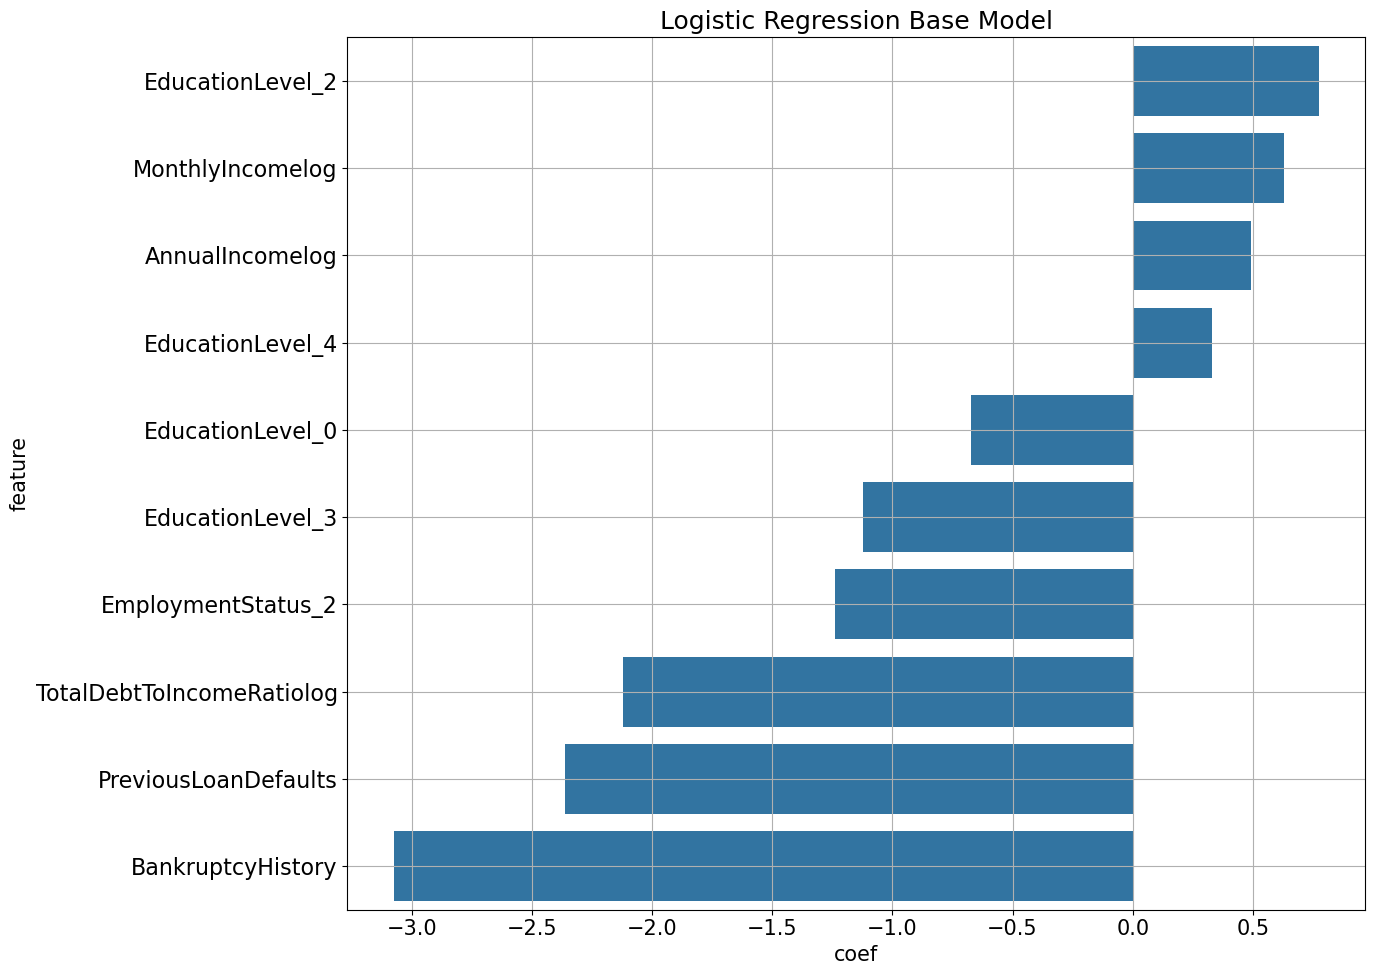

In [42]:
plt.figure(figsize=(14,10))
plt.rcParams.update({'font.size':15})
filter_logobs = np.abs(baselinefeature['coef']) >0.25
#sns.barplot(baselinefeature[filter_logobs], x='coef', y='feature')
sns.barplot(baselinefeature[filter_logobs], x='coef', y='feature')
plt.yticks(fontsize=16)
plt.grid(True)
plt.title('Logistic Regression Base Model')
plt.tight_layout()
plt.show()

The performance metrics for the base model are below.
- We can see that the training and validation scores are close, implying that the model is not over fitting
- AUC is showing that the base model is performing well, compared to random guessing
- f1-score is also showing reasonable performance.

Confusion Matrix can be seen below

In [43]:
y_vanila_train_hat = lg_obs.predict(x_train_obs[col_obs_sel])
pd.crosstab(y_train_obs, y_vanila_train_hat, normalize=True)*100

col_0,0,1
LoanApproved,,
0,42.435940,7.564060
1,6.159658,43.840342


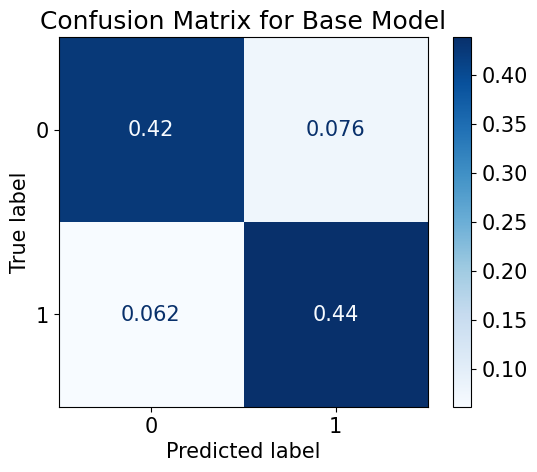

In [44]:
# plt.figure(figsize=(14,4))
plt.rcParams.update({'font.size': 15})
ConfusionMatrixDisplay.from_estimator(lg_obs, x_train_obs[col_obs_sel], y_train_obs, cmap=plt.cm.Blues, normalize='all')
plt.title('Confusion Matrix for Base Model')

plt.show()

### Lasso Logistic Simple Model

In Lasso logistic, we are passing all the parameters available and and applying L1 regularization for feature selection

In [45]:
X_train_slog, X_test_slog, y_train_slog, y_test_slog = get_parameter_data(df, cat_cols = categorical_columns , num_cols=numerical_columns_plog, 
                                                        drop_cols=[], ohe_cols=ohe_columns, ohe_drop='first', d_poly=False)

In [46]:
params_lasso_s = {'C': np.logspace(-3,2, 10)}
lg_s = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', n_jobs=-1)
grid_logistic_lasso_s = GridSearchCV(estimator=lg_s, param_grid=params_lasso_s, scoring='f1', n_jobs=-1, return_train_score=True, cv=kfold,  )
grid_logistic_lasso_s.fit(X_train_slog, y_train_slog)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(max_iter=1000, n_jobs=-1,
                                          penalty='l1', solver='liblinear'),
             n_jobs=-1,
             param_grid={'C': array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02])},
             return_train_score=True, scoring='f1')

In [47]:
lasso_logistic_s = grid_logistic_lasso_s.best_estimator_
lasso_logs_metric,lasso_logs_tpr, lasso_logs_fpr, _  = get_metrics('logistic_lasso_simple', lasso_logistic_s, X_train_slog, 
                                                                   y_train_slog, X_test_slog, y_test_slog)

As we can see below the training and validation set are pretty close, impleing that we are not doing any overfittting. The lasso model is performing better than the baseline model

In [48]:
model_performance.append(lasso_logs_metric)
lasso_logs_metric

{'model_name': 'logistic_lasso_simple',
 'model': LogisticRegression(C=np.float64(0.5994842503189409), max_iter=1000, n_jobs=-1,
                    penalty='l1', solver='liblinear'),
 'accuracy_training': 0.9543774638633377,
 'accuracy_CV': 0.9535159897427553,
 'f1_score_training': 0.9547140586149269,
 'f1_score_CV': 0.9539972709803338,
 'auc': 0.9914794900374879,
 'accuracy_test': 0.941,
 'f1_score_test': 0.884652981427175}

The high impact features are listed below, where positive coefficients have a contruction impact on approval, while the negative coefficiients lowers the changes of lower approval as per the model 

In [49]:
df_lasso_sperf = pd.DataFrame({'feature': lasso_logistic_s.feature_names_in_.tolist(), 'coef':lasso_logistic_s.coef_.tolist()[0]}).\
                sort_values(by=['coef'], ascending=False)
display(df_lasso_sperf.head(15)), display(df_lasso_sperf.tail(15))

,feature,coef
37,MonthlyIncomelog,3.205551
3,EducationLevel_2,2.967921
5,EducationLevel_4,2.001587
24,LengthOfCreditHistory,1.351019
40,BaseInterestRatelog,1.309307
35,TotalAssetslog,1.231876
2,EducationLevel_1,0.886227
39,NetWorthlog,0.694699
26,Agelog,0.340897
29,Experiencelog,0.340634


,feature,coef
36,TotalLiabilitieslog,-0.099654
10,HomeOwnershipStatus_2,-0.101092
42,MonthlyLoanPaymentlog,-0.325410
8,MaritalStatus_3,-0.406570
30,LoanAmountlog,-0.712788
11,HomeOwnershipStatus_3,-0.814833
4,EducationLevel_3,-0.901610
28,CreditScorelog,-0.956011
9,HomeOwnershipStatus_1,-1.194490
16,LoanDuration,-1.217150


(None, None)

Lasso Logistic reduced the following features

In [50]:
df_lasso_sperf[df_lasso_sperf['coef']==0]

,feature,coef
17,NumberOfDependents,0.0
38,UtilityBillsPaymentHistorylog,0.0
15,LoanPurpose_4,0.0


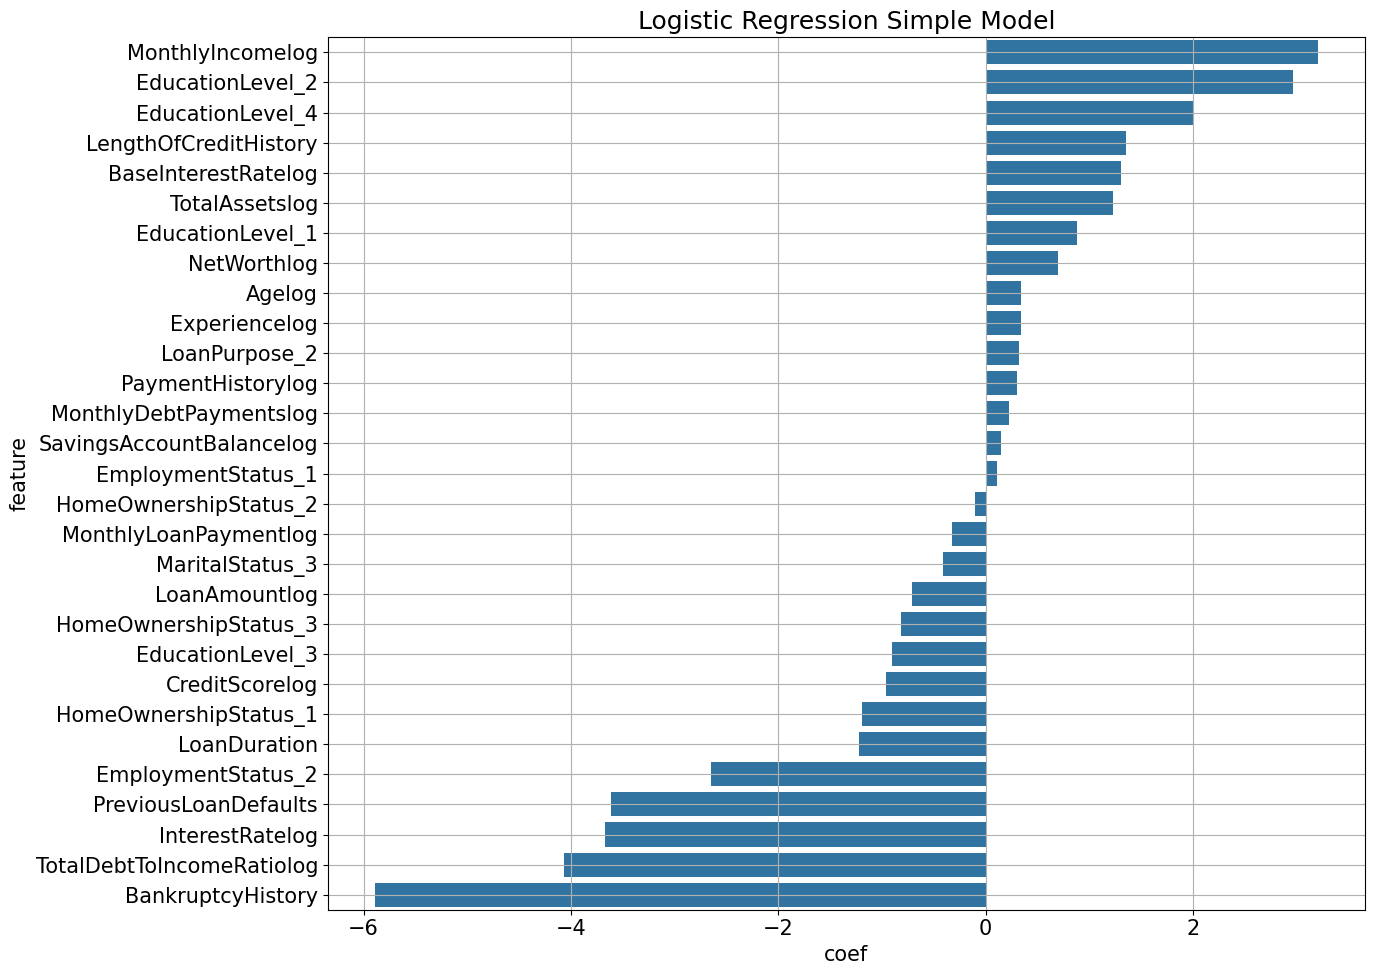

In [51]:
plt.figure(figsize=(14,10))
plt.rcParams.update({'font.size': 15})
filter_lasso_s = np.abs(df_lasso_sperf['coef']) >0.1
sns.barplot(df_lasso_sperf[filter_lasso_s], x='coef', y='feature')
plt.title('Logistic Regression Simple Model')
plt.grid(True)
plt.tight_layout()

In [52]:
y_train_slog_hat = lasso_logistic_s.predict(X_train_slog)
pd.crosstab(y_train_slog, y_train_slog_hat, normalize=True)*100

col_0,0,1
LoanApproved,,
0,47.347240,2.652760
1,1.909494,48.090506


Text(0.5, 1.0, 'Confusion Matrix for Lasso Simple Model')

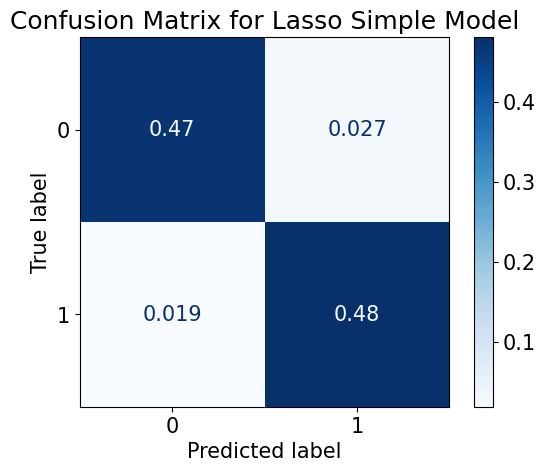

In [53]:
plt.rcParams.update({'font.size': 15})
ConfusionMatrixDisplay.from_predictions(y_train_slog, y_train_slog_hat, cmap=plt.cm.Blues, normalize='all')
plt.title('Confusion Matrix for Lasso Simple Model')

### Lasso Logistic Poly Model

The logistic model uses all the features of the dataset along with interaction terms created. The interaction terms created here are just between the categorical and numerical columns.

In [54]:
X_train_plog, X_test_plog, y_train_plog, y_test_plog = get_parameter_data(df, cat_cols = categorical_columns , num_cols=numerical_columns_plog, 
                                                        drop_cols=[], ohe_cols=ohe_columns, ohe_drop='first', d_poly=True)

In [55]:
params_lasso_p = {'C': np.logspace(-3,2, 10)}
lg_p = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', n_jobs=-1)
grid_logistic_lasso_p = GridSearchCV(estimator=lg_p, param_grid=params_lasso_p, scoring='f1', n_jobs=-1, return_train_score=True, cv=kfold,  )
grid_logistic_lasso_p.fit(X_train_plog, y_train_plog)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(max_iter=1000, n_jobs=-1,
                                          penalty='l1', solver='liblinear'),
             n_jobs=-1,
             param_grid={'C': array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02])},
             return_train_score=True, scoring='f1')

In [56]:
lasso_logistic_p = grid_logistic_lasso_p.best_estimator_
lasso_logp_metric,lasso_logp_tpr, lasso_logp_fpr, _  = get_metrics('logistic_lasso_poly', lasso_logistic_p, X_train_plog, y_train_plog,
                                                                  X_test_plog, y_test_plog)

The moodel performance is slightly better than the simple Lasso Logistic model.

In [57]:
model_performance.append(lasso_logp_metric)
lasso_logp_metric

{'model_name': 'logistic_lasso_poly',
 'model': LogisticRegression(C=np.float64(0.1668100537200059), max_iter=1000, n_jobs=-1,
                    penalty='l1', solver='liblinear'),
 'accuracy_training': 0.9609477660972404,
 'accuracy_CV': 0.9565138014574798,
 'f1_score_training': 0.9612800781727129,
 'f1_score_CV': 0.9568251780276371,
 'auc': 0.991982771627173,
 'accuracy_test': 0.94075,
 'f1_score_test': 0.882962962962963}

In [58]:
df_lasso_pperf = pd.DataFrame({'feature': lasso_logistic_p.feature_names_in_.tolist(), 'coef':lasso_logistic_p.coef_.tolist()[0]}).\
                sort_values(by=['coef'], ascending=False)
display(df_lasso_pperf.head(15)), display(df_lasso_pperf.tail(15))

,feature,coef
3,EducationLevel_2,2.625372
37,MonthlyIncomelog,2.578147
24,LengthOfCreditHistory,1.324221
5,EducationLevel_4,1.242770
35,TotalAssetslog,0.787593
40,BaseInterestRatelog,0.759772
27,AnnualIncomelog,0.750082
39,NetWorthlog,0.543313
157,EducationLevel_3 TotalAssetslog,0.487390
2,EducationLevel_1,0.437175


,feature,coef
189,EducationLevel_4 InterestRatelog,-0.355366
30,LoanAmountlog,-0.403950
42,MonthlyLoanPaymentlog,-0.450244
138,EducationLevel_2 MonthlyLoanPaymentlog,-0.525565
11,HomeOwnershipStatus_3,-0.800268
16,LoanDuration,-0.824990
4,EducationLevel_3,-0.929485
191,EducationLevel_4 TotalDebtToIncomeRatiolog,-0.962476
9,HomeOwnershipStatus_1,-1.062336
28,CreditScorelog,-1.092241


(None, None)

BankruptcyHistory, InterestRate, DebttoIncomeRatio and EmploymentStatus negatively impacted the load application, where as MonthlyIcomeEducationHistory, LengthofCreditHistory and TotalAssests had a positive impact on the loan approval application. This is inline with our understanding of the approval process.
It is also worth noting that 233 out of 460 features were reduced to zero

In [59]:
print("Features reduced to 0 coefficient = ",len(df_lasso_pperf[df_lasso_pperf['coef']==0]['feature'].to_list()))
print("Total Features", X_train_plog.shape[1])

Features reduced to 0 coefficient =  230
Total Features 460


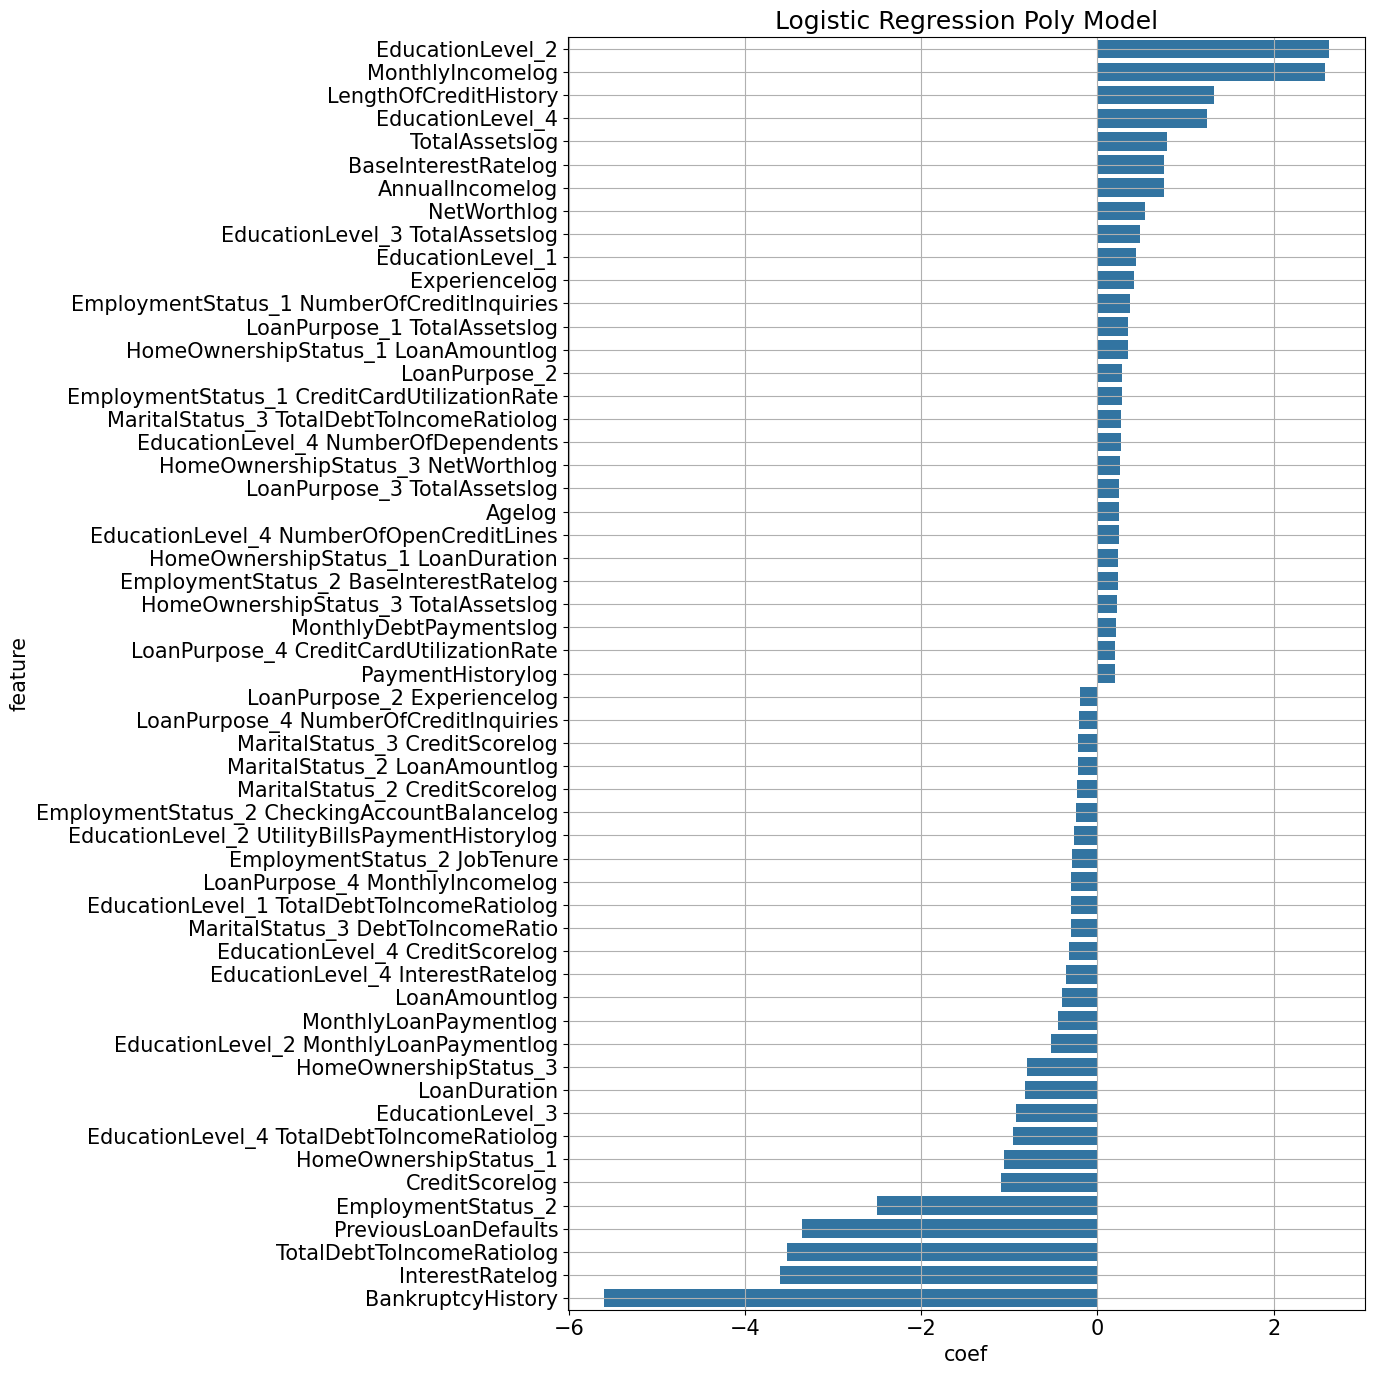

In [60]:
plt.figure(figsize=(14,14))
plt.rcParams.update({'font.size': 15})
# sns.set_style("whitegrid")

filter_lasso_p = np.abs(df_lasso_pperf['coef']) >0.2
sns.barplot(df_lasso_pperf[filter_lasso_p], x='coef', y='feature')
plt.grid(True)
plt.title('Logistic Regression Poly Model')
plt.tight_layout()
plt.show()

In [61]:
y_train_plog_hat = lasso_logistic_p.predict(X_train_plog)
pd.crosstab(y_train_plog, y_train_plog_hat, normalize=True)*100

col_0,0,1
LoanApproved,,
0,47.618265,2.381735
1,1.523489,48.476511


Text(0.5, 1.0, 'Confusion Matrix for Lasso Poly Model')

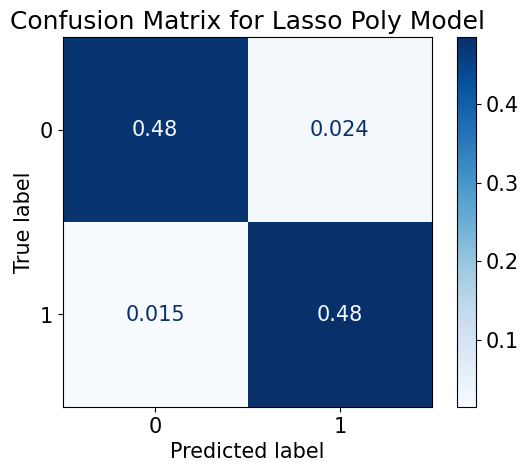

In [62]:
plt.rcParams.update({'font.size': 15})
ConfusionMatrixDisplay.from_predictions(y_train_plog, y_train_plog_hat, cmap=plt.cm.Blues, normalize='all')
plt.title('Confusion Matrix for Lasso Poly Model')

### Random Forest Simple Model

In Random Forest, we are taking all the features of the dataset. Kindly note that we are not dropping any variables while performing one-hot-encoding for our categorical variables

In [63]:
X_train_stree, X_test_stree, y_train_stree, y_test_stree = get_parameter_data(df, cat_cols = categorical_columns , num_cols=numerical_columns_plog, 
                                                        drop_cols=[], ohe_cols=ohe_columns, ohe_drop=None, d_poly=False)

In [64]:
# param_rfs = {# 'n_estimators': [400, 500, 600, 800, 1000],
#                         'n_estimators': [500, 800, 1000],
#                         'criterion': ['gini', 'entropy'],
#                     'max_depth': [7, 10, 13, 15],
#                     # 'max_features': ['sqrt', 'log2'],
#                     'max_features': ['sqrt'],
#                     'ccp_alpha': [0.0, 0.03, 0.07, 0.1],
#                     'max_leaf_nodes': [7, 10, 13, 17, 20, 23]
#                     # 'ccp_alpha': [0.0, 0.03]
#                        # 'max_features'=int(len(X_train_sm.columns)/3),
#                         }


param_rfs = {# 'n_estimators': [400, 500, 600, 800, 1000],
                        # 'n_estimators': [500, 700, 1000, 1300],
                        'n_estimators': [1300],
                        'criterion': ['gini'],
                    # 'max_depth': [17, 20, 23, 27, 30],
                    'max_depth': [20],
                    # 'max_features': ['sqrt', 'log2'],
                    'max_features': ['sqrt'],
                    # 'ccp_alpha': [0, 0.01, 0.03],
                    # 'max_leaf_nodes': [None, 10, 13, 17, 20]
                    'ccp_alpha': [0.0]
                       # 'max_features'=int(len(X_train_sm.columns)/3),
                        }

rfs = RandomForestClassifier(
        # max_depth=None,
                               # n_estimators=1000,
                               # max_features=int(len(X_train_sm.columns)/3),
                                 # max_features='sqrt',
                               # oob_score=True, 
                                warm_start=True,
                               random_state=109, n_jobs=-1)
    
    
grid_rfs = GridSearchCV(rfs, param_grid=param_rfs, scoring='f1', n_jobs=-1, cv=kfold, return_train_score=True)
grid_rfs.fit(X_train_stree, y_train_stree)


GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=109,
                                              warm_start=True),
             n_jobs=-1,
             param_grid={'ccp_alpha': [0.0], 'criterion': ['gini'],
                         'max_depth': [20], 'max_features': ['sqrt'],
                         'n_estimators': [1300]},
             return_train_score=True, scoring='f1')

In [65]:
rfs = grid_rfs.best_estimator_
rfs_metric,rfs_tpr, rfs_fpr, _  = get_metrics('random_forest_simple', rfs, X_train_stree, y_train_stree, X_test_stree, y_test_stree)

The best paramters for the model can be seen below

In [66]:
grid_rfs.best_params_

{'ccp_alpha': 0.0,
 'criterion': 'gini',
 'max_depth': 20,
 'max_features': 'sqrt',
 'n_estimators': 1300}

In [67]:
model_performance.append(rfs_metric)
rfs_metric

{'model_name': 'random_forest_simple',
 'model': RandomForestClassifier(max_depth=20, n_estimators=1300, n_jobs=-1,
                        random_state=109, warm_start=True),
 'accuracy_training': 1.0,
 'accuracy_CV': 0.9588545205522184,
 'f1_score_training': 1.0,
 'f1_score_CV': 0.9592285020702972,
 'auc': 0.9941064507676289,
 'accuracy_test': 0.9295,
 'f1_score_test': 0.8574317492416582}

In [68]:
df_rfs_perf = pd.DataFrame({'feature':rfs.feature_names_in_, 'importance': rfs.feature_importances_}).sort_values(by=['importance'], ascending=False)

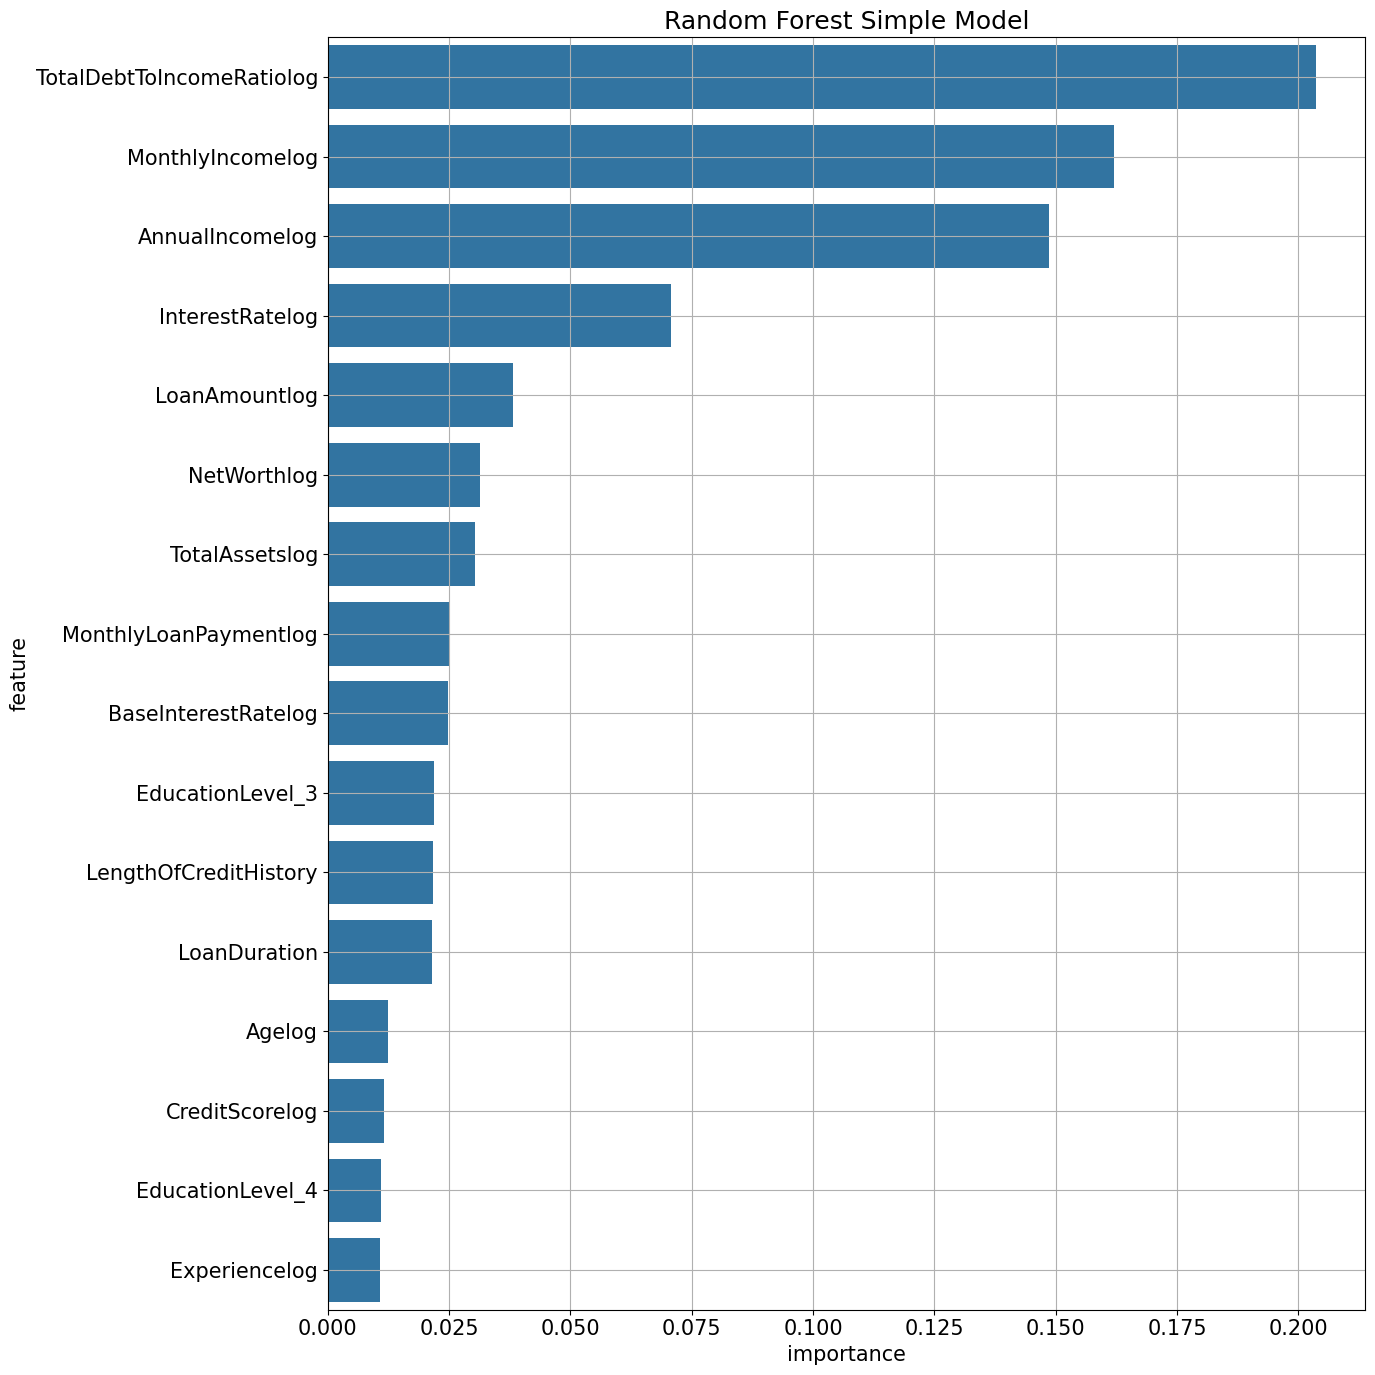

In [69]:
plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(14,14))

# sns.set_style("whitegrid")

filter_rfs = np.abs(df_rfs_perf['importance']) >0.01
sns.barplot(df_rfs_perf[filter_rfs], x='importance', y='feature')
plt.grid(True)
plt.title('Random Forest Simple Model')
plt.tight_layout()
plt.show()

The best parameters can be seen above. The performance of the model is close to logistic regression. The model is overfitting on the training data as can be seen from the f1 score of the training data. We tried forcing regularization, but the validation set performance degraded as a result of it, therefore we had to go with the overfitted model.

In [70]:
y_train_stree_hat = rfs.predict(X_train_stree)
pd.crosstab(y_train_stree, y_train_stree_hat, normalize=True)*100

col_0,0,1
LoanApproved,,
0,50.0,0.0
1,0.0,50.0


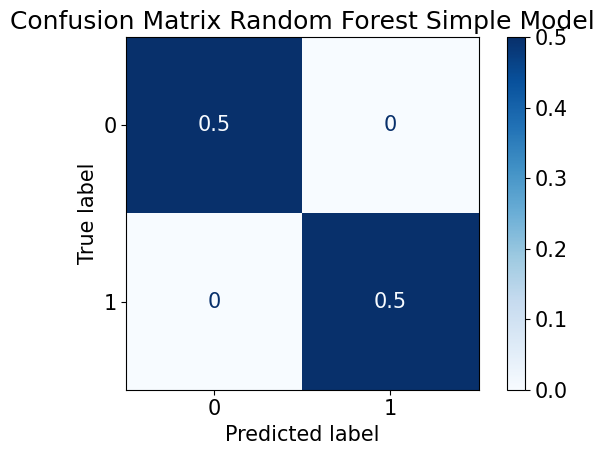

In [71]:
plt.rcParams.update({'font.size': 15})
ConfusionMatrixDisplay.from_predictions(y_train_stree, y_train_stree_hat, cmap=plt.cm.Blues, normalize='all')
plt.title('Confusion Matrix Random Forest Simple Model')
plt.tight_layout()

### Random Forest Poly Model

In Random Forest Poly model, we are using all the features along with interaction terms between the categorical and numerical variables.

(In the submission report, we are using less parameters for grid search based upon last results, because overall training taking too much time)

In [72]:
X_train_ptree, X_test_ptree, y_train_ptree, y_test_ptree = get_parameter_data(df, cat_cols = categorical_columns , num_cols=numerical_columns_plog, 
                                                        drop_cols=[], ohe_cols=ohe_columns, ohe_drop=None, d_poly=True)

In [73]:
# param_rfp = {# 'n_estimators': [400, 500, 600, 800, 1000],
#                         'n_estimators': [500, 1000, 1300, 1500],
#                         'criterion': ['gini', 'entropy'],
#                     'max_depth': [3, 7, 10, 13],
#                     'max_features': ['log2'],
#                     # 'max_features': ['sqrt', 'log2'],
#                     'ccp_alpha': [0.0, 0.01, 0.03, 0.07, 0.1],
#                     'max_leaf_nodes': [3, 7, 10, 13, 17, 20, 23]
#                     # 'ccp_alpha': [0.0, 0.03]
#                        # 'max_features'=int(len(X_train_sm.columns)/3),
#                         }

param_rfp = {# 'n_estimators': [400, 500, 600, 800, 1000],
                        # 'n_estimators': [1000, 1300, 1500],
                        'n_estimators': [1300],
                        # 'criterion': ['gini', 'Entropy'],
                    'criterion': ['gini'],
                     'max_depth': [23],
    
                    # 'max_depth': [20, 23, 27],
                    'max_features': ['sqrt'],
                    # 'max_features': ['auto', 'sqrt'],
                    # 'max_features': ['auto', 'sqrt', 0.1, 0.2, 0.3],
                    # 'ccp_alpha': [0.0, 0.01],
                    'ccp_alpha': [0.0,],
                    # 'max_leaf_nodes': [None, 10, 13, 17, 20]
                    # 'ccp_alpha': [0.0, 0.03]
                       # 'max_features'=int(len(X_train_sm.columns)/3),
                        }

rfp = RandomForestClassifier(
        # max_depth=None,
                               # n_estimators=1000,
                               # max_features=int(len(X_train_sm.columns)/3),
                                 # max_features='sqrt',
                               # oob_score=True, 
                                warm_start =True,
                               random_state=109, n_jobs=-1)
    
    
grid_rfp = GridSearchCV(rfp, param_grid=param_rfp, scoring='f1', n_jobs=-1, cv=kfold, return_train_score=True)
grid_rfp.fit(X_train_ptree, y_train_ptree)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=109,
                                              warm_start=True),
             n_jobs=-1,
             param_grid={'ccp_alpha': [0.0], 'criterion': ['gini'],
                         'max_depth': [23], 'max_features': ['sqrt'],
                         'n_estimators': [1300]},
             return_train_score=True, scoring='f1')

In [74]:
rfp = grid_rfp.best_estimator_
rfp_metric,rfp_tpr, rfp_fpr, _  = get_metrics('random_forest_poly', rfp, X_train_ptree, y_train_ptree, X_test_ptree, y_test_ptree)

In [75]:
grid_rfp.best_params_

{'ccp_alpha': 0.0,
 'criterion': 'gini',
 'max_depth': 23,
 'max_features': 'sqrt',
 'n_estimators': 1300}

In [76]:
model_performance.append(rfp_metric)
rfp_metric

{'model_name': 'random_forest_poly',
 'model': RandomForestClassifier(max_depth=23, n_estimators=1300, n_jobs=-1,
                        random_state=109, warm_start=True),
 'accuracy_training': 0.9999178712220762,
 'accuracy_CV': 0.9496976153128539,
 'f1_score_training': 0.9999178644763861,
 'f1_score_CV': 0.9501069143986298,
 'auc': 0.9913170941392213,
 'accuracy_test': 0.91025,
 'f1_score_test': 0.8244498777506113}

In [77]:
df_rfp_perf = pd.DataFrame({'feature':rfp.feature_names_in_, 'importance': rfp.feature_importances_}).sort_values(by=['importance'], ascending=False)

In [78]:
df_rfp_perf

,feature,importance
48,TotalDebtToIncomeRatiolog,0.064305
42,MonthlyIncomelog,0.052614
32,AnnualIncomelog,0.050532
66,EmploymentStatus_0 TotalDebtToIncomeRatiolog,0.046504
50,EmploymentStatus_0 AnnualIncomelog,0.036754
...,...,...
356,MaritalStatus_3 NumberOfDependents,0.000133
360,MaritalStatus_3 JobTenure,0.000131
124,EmploymentStatus_2 NumberOfCreditInquiries,0.000128
122,EmploymentStatus_2 NumberOfDependents,0.000111


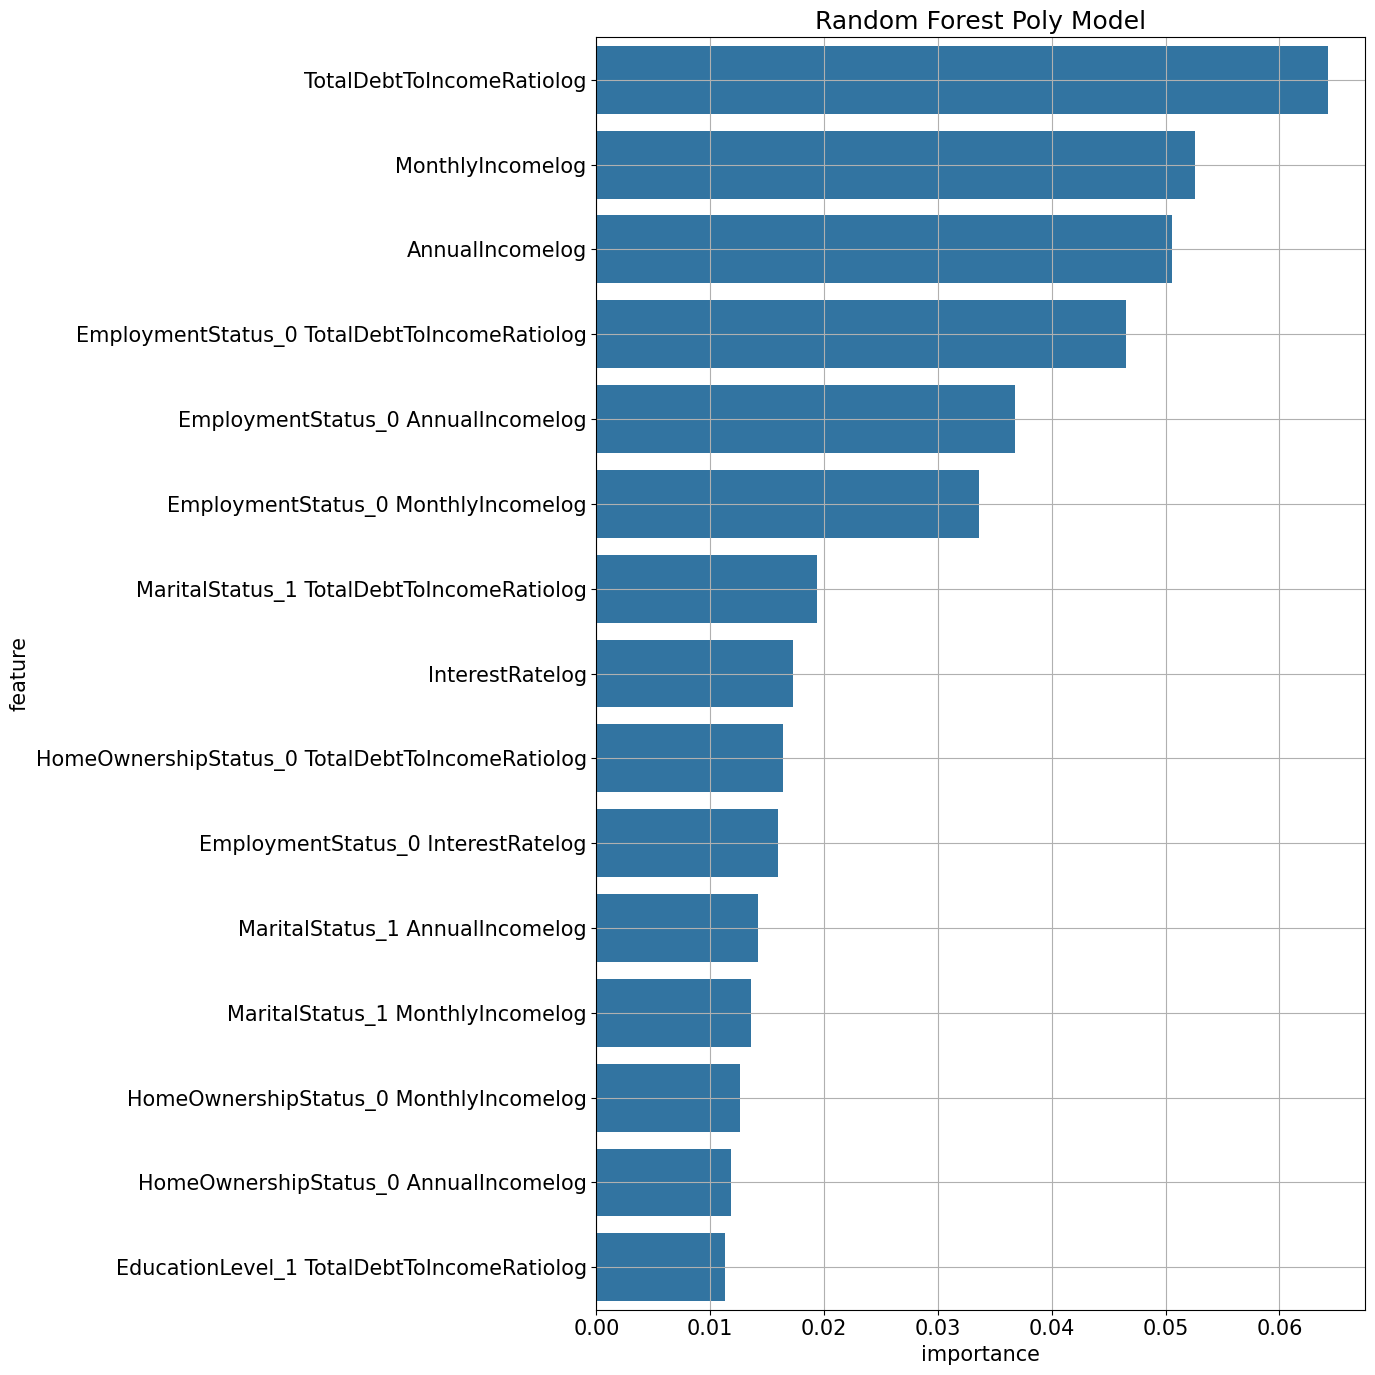

In [79]:
plt.figure(figsize=(14,14))
plt.rcParams.update({'font.size': 15})
# sns.set_style("whitegrid")

filter_rfp = np.abs(df_rfp_perf['importance']) > 0.01
sns.barplot(df_rfp_perf[filter_rfp], x='importance', y='feature')
plt.grid(True)
plt.title('Random Forest Poly Model')
plt.tight_layout()
plt.show()

In [80]:
y_train_ptree_hat = rfp.predict(X_train_ptree)
pd.crosstab(y_train_ptree, y_train_ptree_hat, normalize=True)*100

col_0,0,1
LoanApproved,,
0,50.000000,0.000000
1,0.008213,49.991787


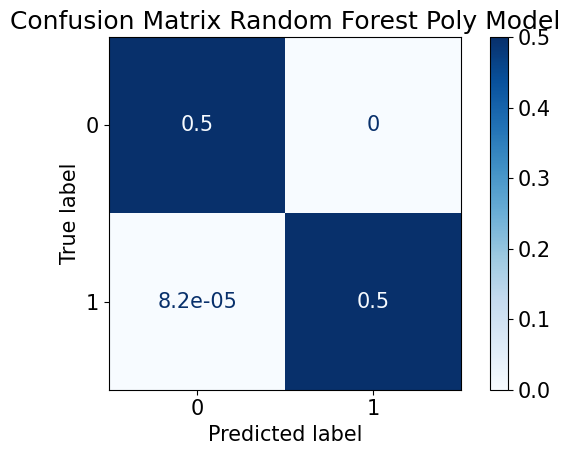

In [81]:
plt.rcParams.update({'font.size': 15})
ConfusionMatrixDisplay.from_predictions(y_train_ptree, y_train_ptree_hat, cmap=plt.cm.Blues, normalize='all')
plt.title('Confusion Matrix Random Forest Poly Model')
plt.tight_layout()
plt.show()

### XGBoost Simple Model

For XGBoost, we are only using the direct terms, since it is taking alot more time to train. We tried running the model with depthwise growth and loss guided tree, where the depthwise was always giving the best results.
We are also tuning the L1 loss for feature selection and learning rate to get the best results.

(In the submission report, we are using less parameters for grid search based upon last results, because overall training taking too much time)

In [82]:
param_xgb_grid = {
                'learning_rate': [0.1], 'max_depth':[ 7], 'n_estimators': [800], 'reg_alpha': [0.04]
                # 'max_depth': [5, 7, 10],
                # 'max_depth': [13, 18, 21],
                 # 'n_estimators': [600, 800, 1000],
                  # 'learning_rate': [0.05, 0.1, 0.15,],
                  # 'learning_rate': [0.05,0.1]
                    # 'grow_policy' : ['depthwise', 'lossguide'],
                # 'reg_alpha': [0, 0.01, 0.04],
                 }

xgbcs = xgb.XGBClassifier(objective='binary:logistic',
                          eval_metric='aucpr',
                        random_state=109, n_jobs=-1
                        )
xgb_grid_s = GridSearchCV(estimator=xgbcs, param_grid=param_xgb_grid, cv=kfold, scoring='f1', n_jobs=-1)

In [83]:
xgb_grid_s.fit(X_train_stree, y_train_stree)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='aucpr', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=No...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None,
                                     random_state=109, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1], 'max_depth': [7],
                         'n_estimators': [800], 'reg_alpha': [0.04]},
             scoring='f1')

In [84]:
xgbs = xgb_grid_s.best_estimator_
xgbs_metric,xgbs_tpr, xgbs_fpr, _  = get_metrics('XGBoost_simple', xgbs, X_train_stree, y_train_stree, X_test_stree, y_test_stree)

In [85]:
model_performance.append(xgbs_metric)
xgbs_metric

{'model_name': 'XGBoost_simple',
 'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='aucpr', feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=7, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=800, n_jobs=-1,
               num_parallel_tree=None, random_state=109, ...),
 'accuracy_training': 1.0,
 'accuracy_CV': 0.9720367830899633,
 'f1_score_training': 1.0,
 'f1_score_CV': 0.9715017186961041,
 'auc': 0.9973132874811567,
 'accuracy_test': 0.9545,
 'f1_score_te

In [86]:
xgb_grid_s.best_params_

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 800, 'reg_alpha': 0.04}

In [87]:
df_xgb_s = pd.DataFrame({'feature':xgbs.feature_names_in_, 'importance': xgbs.feature_importances_}).sort_values(by=['importance'], ascending=False)

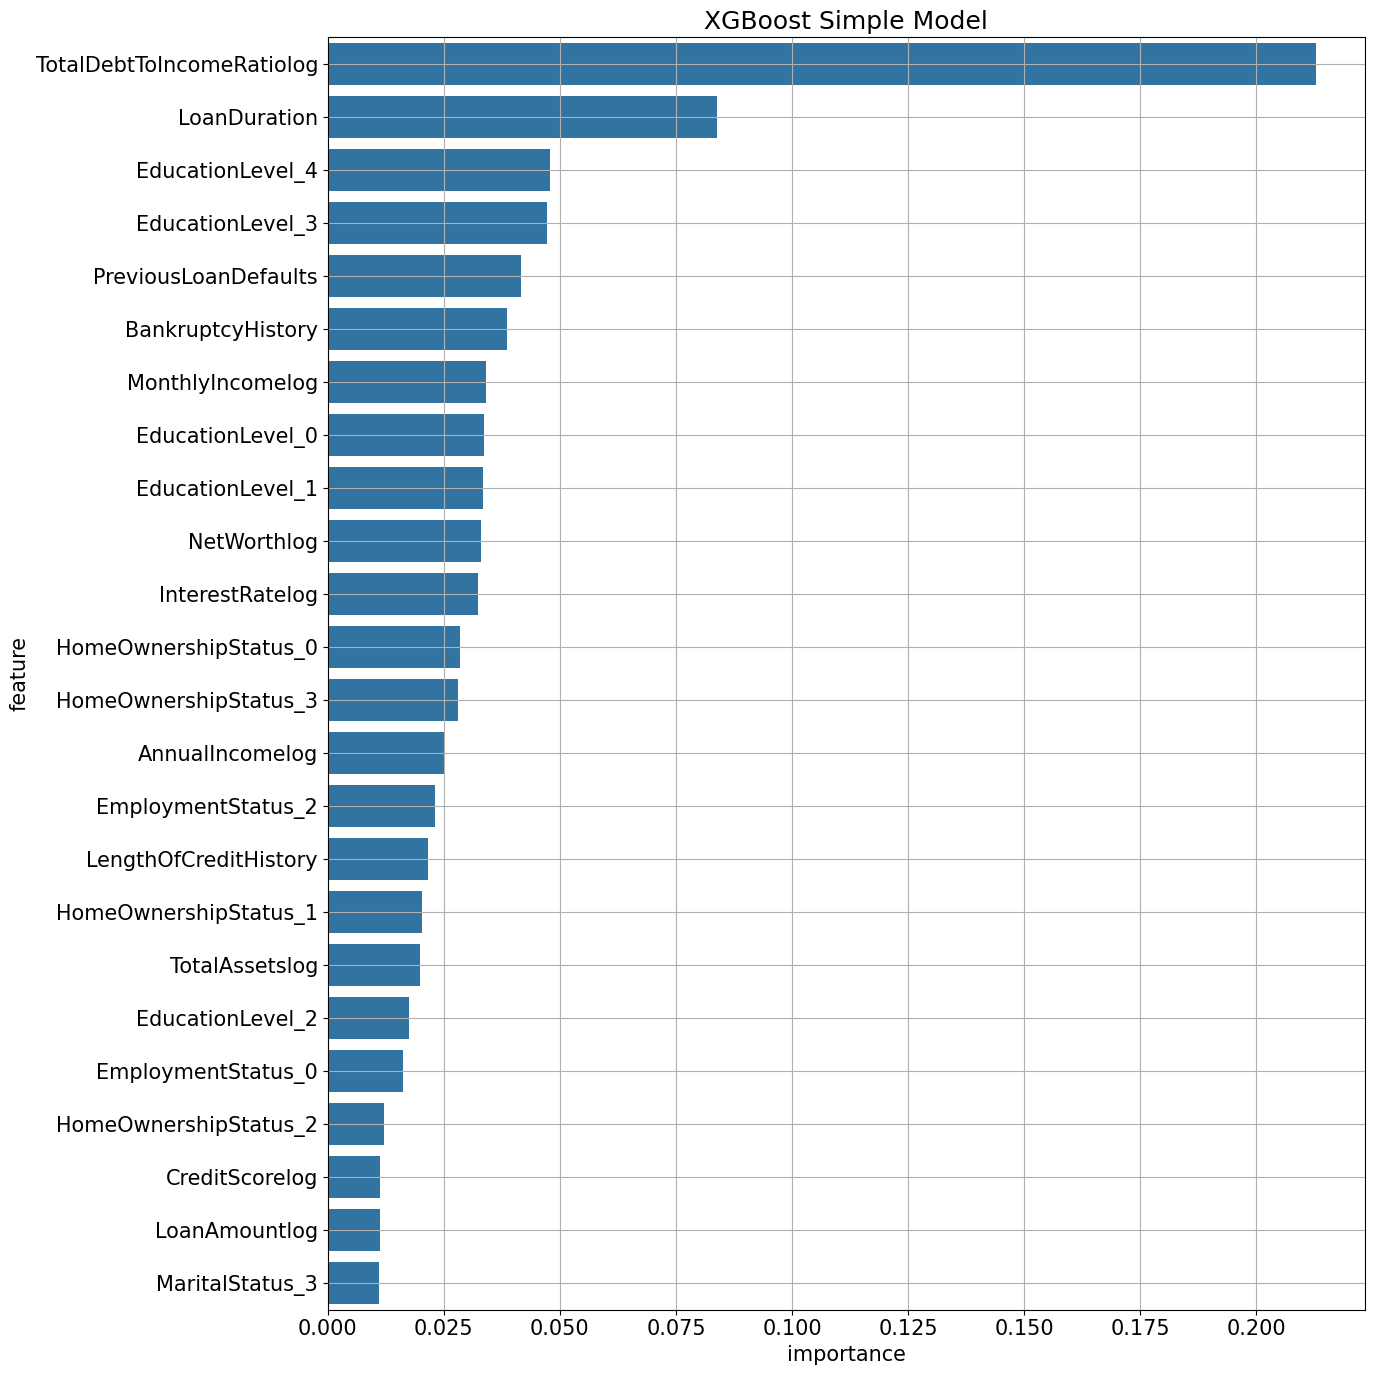

In [88]:
plt.figure(figsize=(14,14))
plt.rcParams.update({'font.size': 15})
# sns.set_style("whitegrid")

filter_xgbs = np.abs(df_xgb_s['importance']) > 0.01
sns.barplot(df_xgb_s[filter_xgbs], x='importance', y='feature')
plt.grid(True)
plt.title('XGBoost Simple Model')
plt.tight_layout()
plt.show()

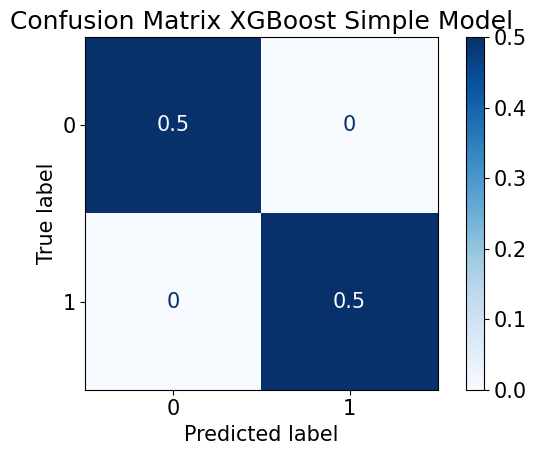

In [89]:
plt.rcParams.update({'font.size': 15})
ConfusionMatrixDisplay.from_estimator(xgbs, X_train_stree, y_train_ptree, cmap=plt.cm.Blues, normalize='all')
# plt.grid(False)
plt.title('Confusion Matrix XGBoost Simple Model')
plt.tight_layout()

### Stacked Model

The stacked model is using Logistic Lasso simple, Random Forest Simple and XGBoost simple with passthrough option set to True

In [90]:
estimator = [
    ('logistic_Lasso_s', lasso_logistic_s),
            ('Random Forest', rfs),
              ('XGBoost Simple', xgbcs)]
stk = StackingClassifier(estimators=estimator, final_estimator=LogisticRegression(), n_jobs=-1, cv=kfold, passthrough=True)

In [91]:
stk.fit(X_train_stree, y_train_stree)

StackingClassifier(cv=KFold(n_splits=5, random_state=RandomState(MT19937) at 0x1E6EEF9CD40,
   shuffle=False),
                   estimators=[('logistic_Lasso_s',
                                LogisticRegression(C=np.float64(0.5994842503189409),
                                                   max_iter=1000, n_jobs=-1,
                                                   penalty='l1',
                                                   solver='liblinear')),
                               ('Random Forest',
                                RandomForestClassifier(max_depth=20,
                                                       n_estimators=1300,
                                                       n_jobs=-1,
                                                       random_state=109,
                                                       warm_sta...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=-1,
                                              num_parallel_tree=None,
                                              random_state=109, ...))],
                   final_estimator=LogisticRegression(), n_jobs=-1,
                   passthrough=True)

In [92]:
stk_metric,stk_tpr, stk_fpr, stk_threshold  = get_metrics('stacked_model', stk, X_train_stree, y_train_stree, X_test_stree, y_test_stree)

In [93]:
model_performance.append(stk_metric)
stk_metric

{'model_name': 'stacked_model',
 'model': StackingClassifier(cv=KFold(n_splits=5, random_state=RandomState(MT19937) at 0x1E6EEF9CD40,
    shuffle=False),
                    estimators=[('logistic_Lasso_s',
                                 LogisticRegression(C=np.float64(0.5994842503189409),
                                                    max_iter=1000, n_jobs=-1,
                                                    penalty='l1',
                                                    solver='liblinear')),
                                ('Random Forest',
                                 RandomForestClassifier(max_depth=20,
                                                        n_estimators=1300,
                                                        n_jobs=-1,
                                                        random_state=109,
                                                        warm_sta...
                                               interaction_constraints=None,
        

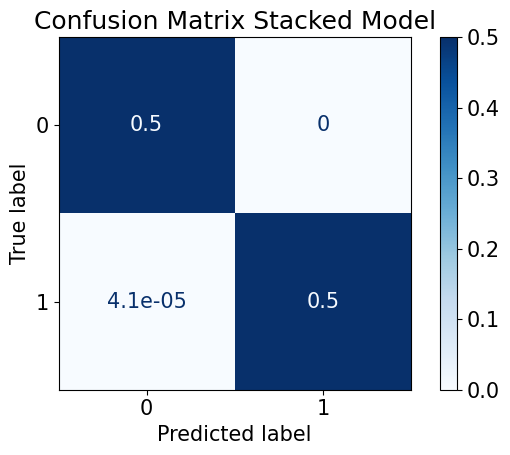

In [94]:
plt.rcParams.update({'font.size': 15})
ConfusionMatrixDisplay.from_estimator(stk, X_train_stree, y_train_ptree, cmap=plt.cm.Blues, normalize='all')
# plt.grid(False)
plt.title('Confusion Matrix Stacked Model')
plt.tight_layout()

## Model Comparison

### Model Performance

Here ishow the model performance looks like.Stacked model is showing the best performance.

In [95]:
df_model_perf = pd.DataFrame(model_performance).drop(['model','accuracy_test','f1_score_test'], axis=1)
df_model_perf

,model_name,accuracy_training,accuracy_CV,f1_score_training,f1_score_CV,auc
0,logistic_base,0.862763,0.860916,0.864663,0.862520,0.938743
1,logistic_lasso_simple,0.954377,0.953516,0.954714,0.953997,0.991479
2,logistic_lasso_poly,0.960948,0.956514,0.961280,0.956825,0.991983
3,random_forest_simple,1.000000,0.958855,1.000000,0.959229,0.994106
4,random_forest_poly,0.999918,0.949698,0.999918,0.950107,0.991317
5,XGBoost_simple,1.000000,0.972037,1.000000,0.971502,0.997313
6,stacked_model,0.999959,0.976184,0.999959,0.975863,0.997844


### ROC Curve

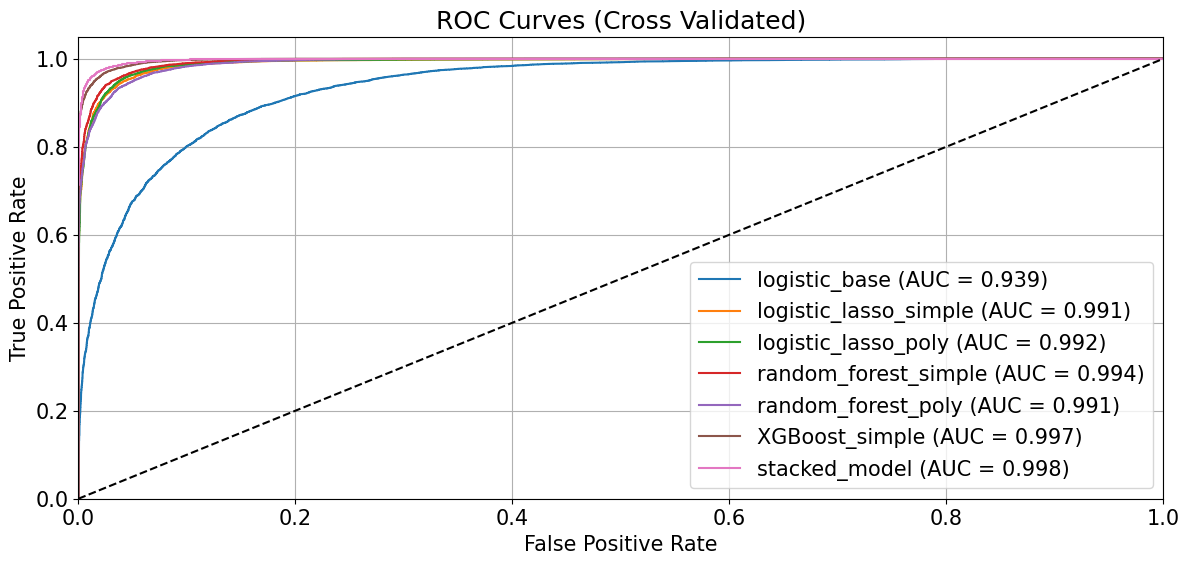

In [96]:
plt.figure(figsize=(14,6))
model_names = {'logistic_base': [lg_obs_tpr, lg_obs_fpr],
                'logistic_lasso_simple': [lasso_logs_tpr, lasso_logs_fpr],
                'logistic_lasso_poly':[lasso_logp_tpr, lasso_logp_fpr],
                'random_forest_simple':[rfs_tpr, rfs_fpr],
                'random_forest_poly':[rfp_tpr, rfp_fpr],
                'XGBoost_simple':[xgbs_tpr, xgbs_fpr],
                'stacked_model':[stk_tpr,stk_fpr] }

for model_name, models_vals in model_names.items():
    tpr, fpr = models_vals
    filt22 = df_model_perf['model_name'] == model_name
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {df_model_perf[filt22]['auc'].item():.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves (Cross Validated)')
plt.legend(loc="lower right")
plt.grid(True)
plt.legend()
plt.show()
# print(f'Best threhold {threshold[np.argmax(tpr - fpr)]}')

## Test Score
Here is how the test scores look like for the stacked model

In [97]:
df_model_perf = pd.DataFrame(model_performance)
df_model_perf[df_model_perf['model_name']=='stacked_model']

,model_name,model,accuracy_training,accuracy_CV,f1_score_training,f1_score_CV,auc,accuracy_test,f1_score_test
6,stacked_model,"StackingClassifier(cv=KFold(n_splits=5, random...",0.999959,0.976184,0.999959,0.975863,0.997844,0.958,0.911205


The f1-score on test set is lower compared to CV set. Comparing with the test scores with all the other models, shows stacked model performed the best

In [98]:
df_model_perf.drop(columns=['model'], axis=1)

,model_name,accuracy_training,accuracy_CV,f1_score_training,f1_score_CV,auc,accuracy_test,f1_score_test
0,logistic_base,0.862763,0.860916,0.864663,0.862520,0.938743,0.85125,0.732584
1,logistic_lasso_simple,0.954377,0.953516,0.954714,0.953997,0.991479,0.94100,0.884653
2,logistic_lasso_poly,0.960948,0.956514,0.961280,0.956825,0.991983,0.94075,0.882963
3,random_forest_simple,1.000000,0.958855,1.000000,0.959229,0.994106,0.92950,0.857432
4,random_forest_poly,0.999918,0.949698,0.999918,0.950107,0.991317,0.91025,0.824450
5,XGBoost_simple,1.000000,0.972037,1.000000,0.971502,0.997313,0.95450,0.905208
6,stacked_model,0.999959,0.976184,0.999959,0.975863,0.997844,0.95800,0.911205


## Conclusion

- Based upon the model performance, we are seeing that XGBoost is showing the best performance on the validation set. However the stacked model is the best performing. Stacked version is the final version.
- Stacking used Logistic Lasso simple, Random Forest Simple and XGBoost simple
- The best AUC is seen to be of XGBoost, performing significanlt better than other models
- The ensemble models are are overfitting in the training set as can be seen from the f1 score, however when regularization was applied forcefully (by removing None and 0), the validation scores dropped alot, so we had to settle on these models, because of their performance on the validation set

## Future Work

- Further fine tune the final model XGBoost to see if we can further improve the results.

- Perform the same work using under sampling instead of over sampling. Undersampling techniques to be done will be

    - Random Under Sampling
    - Near Miss Under Sampling